In [1]:
from pathlib import Path

import pandas as pd


# ---------------------------------------------------------------------------
# Project paths
# ---------------------------------------------------------------------------

PROJECT_ROOT = Path.cwd().resolve().parent
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

LOAN_CLEAN_FILE = (
    PROCESSED_DATA_DIR / "loan_portfolio_clean.csv"
)


# ---------------------------------------------------------------------------
# Validate processed dataset
# ---------------------------------------------------------------------------

if not LOAN_CLEAN_FILE.exists():
    raise FileNotFoundError(
        f"Clean loan portfolio not found: {LOAN_CLEAN_FILE}"
    )

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data directory: {PROCESSED_DATA_DIR}")

Project root: D:\Bank_sense_2.0
Processed data directory: D:\Bank_sense_2.0\data\processed


In [2]:
# ---------------------------------------------------------------------------
# Load cleaned loan portfolio
# ---------------------------------------------------------------------------

loan_portfolio = pd.read_csv(
    LOAN_CLEAN_FILE,
    low_memory=False,
)

print(
    f"Loaded {len(loan_portfolio):,} loan records "
    f"with {len(loan_portfolio.columns):,} columns."
)

Loaded 50,000 loan records with 29 columns.


In [3]:
# ---------------------------------------------------------------------------
# Define PD modelling target
# ---------------------------------------------------------------------------

TARGET_COLUMN = "defaulted"

if TARGET_COLUMN not in loan_portfolio.columns:
    raise KeyError(
        f"Required target column '{TARGET_COLUMN}' "
        "was not found."
    )

print(
    f"PD target: {TARGET_COLUMN}"
)

print(
    loan_portfolio[TARGET_COLUMN]
    .value_counts()
    .sort_index()
)

PD target: defaulted
defaulted
0    43050
1     6950
Name: count, dtype: int64


In [4]:
# ---------------------------------------------------------------------------
# Build loan-variable inventory
# ---------------------------------------------------------------------------

variable_inventory = pd.DataFrame(
    {
        "variable": loan_portfolio.columns,
        "dtype": loan_portfolio.dtypes.astype(str).values,
        "missing_count": loan_portfolio.isna().sum().values,
        "unique_values": loan_portfolio.nunique(
            dropna=False
        ).values,
    }
)

display(variable_inventory)

,variable,dtype,missing_count,unique_values
0,loan_id,str,0,50000
1,origination_date,str,0,108
2,maturity_date,str,0,109
3,maturity_months,int64,0,7
4,sector,str,0,10
5,loan_type,str,0,5
6,collateral,str,0,3
7,initial_rating,str,0,7
8,credit_score,int64,0,307
9,ead,float64,0,49566


In [5]:
# ---------------------------------------------------------------------------
# Initial variable classification framework
# ---------------------------------------------------------------------------

variable_classification = pd.DataFrame(
    [
        {
            "variable": "loan_id",
            "business_role": "Loan identifier",
            "available_at_origination": True,
            "post_default": False,
            "outcome_derived": False,
            "pd_model_eligible": False,
            "lgd_model_eligible": False,
            "role": "Identifier",
            "reason": "Unique identifier; not a predictive feature.",
        },
        {
            "variable": "origination_date",
            "business_role": "Loan origination date",
            "available_at_origination": True,
            "post_default": False,
            "outcome_derived": False,
            "pd_model_eligible": False,
            "lgd_model_eligible": False,
            "role": "Reference",
            "reason": "Useful for temporal splitting and cohort analysis, not as a raw predictive feature.",
        },
        {
            "variable": "maturity_date",
            "business_role": "Contractual maturity date",
            "available_at_origination": True,
            "post_default": False,
            "outcome_derived": False,
            "pd_model_eligible": False,
            "lgd_model_eligible": False,
            "role": "Reference",
            "reason": "Potentially useful to derive contractual term; avoid using raw date directly.",
        },
        {
            "variable": "maturity_months",
            "business_role": "Contractual loan term",
            "available_at_origination": True,
            "post_default": False,
            "outcome_derived": False,
            "pd_model_eligible": True,
            "lgd_model_eligible": True,
            "role": "Feature",
            "reason": "Known at origination and represents loan structure.",
        },
        {
            "variable": "sector",
            "business_role": "Borrower/industry sector",
            "available_at_origination": True,
            "post_default": False,
            "outcome_derived": False,
            "pd_model_eligible": True,
            "lgd_model_eligible": True,
            "role": "Feature",
            "reason": "Known at origination and relevant to credit risk.",
        },
        {
            "variable": "loan_type",
            "business_role": "Loan product type",
            "available_at_origination": True,
            "post_default": False,
            "outcome_derived": False,
            "pd_model_eligible": True,
            "lgd_model_eligible": True,
            "role": "Feature",
            "reason": "Known at origination; captures loan structure.",
        },
        {
            "variable": "collateral",
            "business_role": "Collateral status",
            "available_at_origination": True,
            "post_default": False,
            "outcome_derived": False,
            "pd_model_eligible": True,
            "lgd_model_eligible": True,
            "role": "Feature",
            "reason": "Known at origination and strongly related to recovery/LGD in this dataset.",
        },
        {
            "variable": "initial_rating",
            "business_role": "Initial credit rating",
            "available_at_origination": True,
            "post_default": False,
            "outcome_derived": False,
            "pd_model_eligible": True,
            "lgd_model_eligible": True,
            "role": "Feature",
            "reason": "Origination-time credit-quality assessment.",
        },
        {
            "variable": "credit_score",
            "business_role": "Credit score",
            "available_at_origination": True,
            "post_default": False,
            "outcome_derived": False,
            "pd_model_eligible": True,
            "lgd_model_eligible": True,
            "role": "Feature",
            "reason": "Origination-time borrower risk indicator.",
        },
        {
            "variable": "ead",
            "business_role": "Exposure at default",
            "available_at_origination": True,
            "post_default": False,
            "outcome_derived": False,
            "pd_model_eligible": False,
            "lgd_model_eligible": False,
            "role": "Risk calculation input",
            "reason": "Central to ECL; feature eligibility depends on how EAD was defined at prediction time.",
        },
        {
            "variable": "coupon_rate",
            "business_role": "Loan interest/coupon rate",
            "available_at_origination": True,
            "post_default": False,
            "outcome_derived": False,
            "pd_model_eligible": True,
            "lgd_model_eligible": True,
            "role": "Feature",
            "reason": "Loan pricing/structure known at origination.",
        },
        {
            "variable": "leverage",
            "business_role": "Leverage ratio",
            "available_at_origination": True,
            "post_default": False,
            "outcome_derived": False,
            "pd_model_eligible": True,
            "lgd_model_eligible": True,
            "role": "Feature",
            "reason": "Borrower financial-risk characteristic available at origination.",
        },
        {
            "variable": "interest_coverage",
            "business_role": "Interest coverage ratio",
            "available_at_origination": True,
            "post_default": False,
            "outcome_derived": False,
            "pd_model_eligible": True,
            "lgd_model_eligible": True,
            "role": "Feature",
            "reason": "Debt-servicing capacity indicator.",
        },
        {
            "variable": "debt_to_equity",
            "business_role": "Debt-to-equity ratio",
            "available_at_origination": True,
            "post_default": False,
            "outcome_derived": False,
            "pd_model_eligible": True,
            "lgd_model_eligible": True,
            "role": "Feature",
            "reason": "Capital-structure risk indicator.",
        },
        {
            "variable": "pd_annual",
            "business_role": "Supplied annual PD estimate",
            "available_at_origination": "Uncertain",
            "post_default": False,
            "outcome_derived": "Potentially",
            "pd_model_eligible": False,
            "lgd_model_eligible": False,
            "role": "Benchmark",
            "reason": "Already a risk estimate; use as a benchmark rather than feeding it into the primary PD model.",
        },
        {
            "variable": "lgd",
            "business_role": "Loss given default estimate",
            "available_at_origination": "Uncertain",
            "post_default": False,
            "outcome_derived": "Potentially",
            "pd_model_eligible": False,
            "lgd_model_eligible": "To investigate",
            "role": "Risk estimate / target candidate",
            "reason": "Used in ECL; requires separate LGD methodology.",
        },
        {
            "variable": "el",
            "business_role": "Expected loss",
            "available_at_origination": False,
            "post_default": True,
            "outcome_derived": True,
            "pd_model_eligible": False,
            "lgd_model_eligible": False,
            "role": "Derived risk metric",
            "reason": "Downstream of PD/LGD/EAD.",
        },
        {
            "variable": "unexpected_loss",
            "business_role": "Unexpected loss",
            "available_at_origination": False,
            "post_default": True,
            "outcome_derived": True,
            "pd_model_eligible": False,
            "lgd_model_eligible": False,
            "role": "Portfolio risk metric",
            "reason": "Downstream risk measure; not an origination predictor.",
        },
        {
            "variable": "rwa",
            "business_role": "Risk-weighted assets",
            "available_at_origination": False,
            "post_default": False,
            "outcome_derived": True,
            "pd_model_eligible": False,
            "lgd_model_eligible": False,
            "role": "Portfolio/regulatory metric",
            "reason": "Derived risk measure rather than borrower-level predictor.",
        },
        {
            "variable": "defaulted",
            "business_role": "Observed default outcome",
            "available_at_origination": False,
            "post_default": True,
            "outcome_derived": True,
            "pd_model_eligible": False,
            "lgd_model_eligible": False,
            "role": "Target",
            "reason": "Primary PD modelling target.",
        },
        {
            "variable": "default_date",
            "business_role": "Date of default",
            "available_at_origination": False,
            "post_default": True,
            "outcome_derived": True,
            "pd_model_eligible": False,
            "lgd_model_eligible": False,
            "role": "Outcome",
            "reason": "Only known after the default event.",
        },
        {
            "variable": "survival_months",
            "business_role": "Time from origination to default",
            "available_at_origination": False,
            "post_default": True,
            "outcome_derived": True,
            "pd_model_eligible": False,
            "lgd_model_eligible": False,
            "role": "Outcome-derived",
            "reason": "Validated as derived from origination and default dates.",
        },
        {
            "variable": "recovery_rate",
            "business_role": "Post-default recovery",
            "available_at_origination": False,
            "post_default": True,
            "outcome_derived": True,
            "pd_model_eligible": False,
            "lgd_model_eligible": True,
            "role": "LGD target/input",
            "reason": "Observed after default and central to recovery/LGD analysis.",
        },
        {
            "variable": "loss_given_default",
            "business_role": "Observed default loss",
            "available_at_origination": False,
            "post_default": True,
            "outcome_derived": True,
            "pd_model_eligible": False,
            "lgd_model_eligible": True,
            "role": "LGD target",
            "reason": "Observed only after default.",
        },
    ]
)

display(variable_classification)

,variable,business_role,available_at_origination,post_default,outcome_derived,pd_model_eligible,lgd_model_eligible,role,reason
0,loan_id,Loan identifier,True,False,False,False,False,Identifier,Unique identifier; not a predictive feature.
1,origination_date,Loan origination date,True,False,False,False,False,Reference,Useful for temporal splitting and cohort analy...
2,maturity_date,Contractual maturity date,True,False,False,False,False,Reference,Potentially useful to derive contractual term;...
3,maturity_months,Contractual loan term,True,False,False,True,True,Feature,Known at origination and represents loan struc...
4,sector,Borrower/industry sector,True,False,False,True,True,Feature,Known at origination and relevant to credit risk.
5,loan_type,Loan product type,True,False,False,True,True,Feature,Known at origination; captures loan structure.
6,collateral,Collateral status,True,False,False,True,True,Feature,Known at origination and strongly related to r...
7,initial_rating,Initial credit rating,True,False,False,True,True,Feature,Origination-time credit-quality assessment.
8,credit_score,Credit score,True,False,False,True,True,Feature,Origination-time borrower risk indicator.
9,ead,Exposure at default,True,False,False,False,False,Risk calculation input,Central to ECL; feature eligibility depends on...


In [6]:
# ---------------------------------------------------------------------------
# Define candidate PD features
# ---------------------------------------------------------------------------

PD_CANDIDATE_FEATURES = [
    "maturity_months",
    "sector",
    "loan_type",
    "collateral",
    "initial_rating",
    "credit_score",
    "coupon_rate",
    "leverage",
    "interest_coverage",
    "debt_to_equity",
]

print(
    f"Candidate PD features: {len(PD_CANDIDATE_FEATURES)}"
)

display(
    variable_classification.loc[
        variable_classification["variable"].isin(
            PD_CANDIDATE_FEATURES
        ),
        [
            "variable",
            "business_role",
            "available_at_origination",
            "pd_model_eligible",
            "reason",
        ],
    ]
)

Candidate PD features: 10


,variable,business_role,available_at_origination,pd_model_eligible,reason
3,maturity_months,Contractual loan term,True,True,Known at origination and represents loan struc...
4,sector,Borrower/industry sector,True,True,Known at origination and relevant to credit risk.
5,loan_type,Loan product type,True,True,Known at origination; captures loan structure.
6,collateral,Collateral status,True,True,Known at origination and strongly related to r...
7,initial_rating,Initial credit rating,True,True,Origination-time credit-quality assessment.
8,credit_score,Credit score,True,True,Origination-time borrower risk indicator.
10,coupon_rate,Loan interest/coupon rate,True,True,Loan pricing/structure known at origination.
11,leverage,Leverage ratio,True,True,Borrower financial-risk characteristic availab...
12,interest_coverage,Interest coverage ratio,True,True,Debt-servicing capacity indicator.
13,debt_to_equity,Debt-to-equity ratio,True,True,Capital-structure risk indicator.


In [7]:
# ---------------------------------------------------------------------------
# Leakage check for candidate PD features
# ---------------------------------------------------------------------------

pd_feature_audit = variable_classification.loc[
    variable_classification["variable"].isin(
        PD_CANDIDATE_FEATURES
    )
].copy()

leakage_flags = pd_feature_audit[
    (
        pd_feature_audit["available_at_origination"]
        != True
    )
    |
    (
        pd_feature_audit["post_default"]
        == True
    )
    |
    (
        pd_feature_audit["outcome_derived"]
        == True
    )
]

display(
    leakage_flags[
        [
            "variable",
            "available_at_origination",
            "post_default",
            "outcome_derived",
            "reason",
        ]
    ]
)

,variable,available_at_origination,post_default,outcome_derived,reason


# PD Feature Eligibility — Initial Decision

The initial PD model will use only variables that can reasonably be available at
loan origination:

- maturity_months
- sector
- loan_type
- collateral
- initial_rating
- credit_score
- coupon_rate
- leverage
- interest_coverage
- debt_to_equity

The following variables are excluded from the primary PD feature set because
they are outcome-derived, post-default, downstream risk metrics, identifiers,
or require separate methodological treatment:

- pd_annual
- el
- unexpected_loss
- rwa
- defaulted
- default_date
- survival_months
- recovery_rate
- loss_given_default
- loan_id

`ead` remains under methodological review because the dataset labels it
Exposure at Default, and its availability at origination must be established
before using it as a predictive feature.

No model training will occur until the feature-timing assumptions are documented.

In [8]:
# ---------------------------------------------------------------------------
# Candidate-feature relationship with observed default
# ---------------------------------------------------------------------------

numeric_pd_features = [
    "maturity_months",
    "credit_score",
    "coupon_rate",
    "leverage",
    "interest_coverage",
    "debt_to_equity",
]

default_feature_summary = (
    loan_portfolio
    .groupby("defaulted")[numeric_pd_features]
    .mean()
    .T
    .rename(
        columns={
            0: "mean_non_defaulted",
            1: "mean_defaulted",
        }
    )
)

default_feature_summary["absolute_difference"] = (
    default_feature_summary["mean_defaulted"]
    - default_feature_summary["mean_non_defaulted"]
).abs()

display(
    default_feature_summary.sort_values(
        "absolute_difference",
        ascending=False,
    )
)

defaulted,mean_non_defaulted,mean_defaulted,absolute_difference
credit_score,719.431731,687.423309,32.008421
maturity_months,52.522091,62.942158,10.420068
coupon_rate,3.029688,3.385077,0.355389
interest_coverage,3.772084,3.714564,0.057520
debt_to_equity,2.092851,2.078699,0.014152
leverage,6.912374,6.922481,0.010107


In [9]:
# ---------------------------------------------------------------------------
# Default rates by categorical candidate features
# ---------------------------------------------------------------------------

categorical_pd_features = [
    "sector",
    "loan_type",
    "collateral",
    "initial_rating",
]

for feature in categorical_pd_features:
    print(f"\n{'=' * 80}")
    print(f"DEFAULT RATE BY: {feature}")
    print(f"{'=' * 80}")

    summary = (
        loan_portfolio
        .groupby(feature)
        .agg(
            loans=("loan_id", "count"),
            defaults=("defaulted", "sum"),
            default_rate=("defaulted", "mean"),
        )
        .sort_values("default_rate", ascending=False)
    )

    summary["default_rate_pct"] = (
        summary["default_rate"] * 100
    )

    display(summary)


DEFAULT RATE BY: sector


,loans,defaults,default_rate,default_rate_pct
sector,,,,
Financials,5023,741,0.147521,14.752140
Energy,5132,742,0.144583,14.458301
Industrials,5012,722,0.144054,14.405427
Retail,4951,696,0.140578,14.057766
Real_Estate,4862,678,0.139449,13.944879
Consumer,5043,691,0.137022,13.702161
Technology,4959,676,0.136318,13.631781
Telecom,5077,685,0.134922,13.492220
Utilities,4959,662,0.133495,13.349466



DEFAULT RATE BY: loan_type


,loans,defaults,default_rate,default_rate_pct
loan_type,,,,
lease,2528,373,0.147547,14.754747
mortgage,12262,1750,0.142717,14.271734
term_loan,17594,2450,0.139252,13.925202
revolving,10158,1413,0.139102,13.910219
bond,7458,964,0.129257,12.925717



DEFAULT RATE BY: collateral


,loans,defaults,default_rate,default_rate_pct
collateral,,,,
partially_secured,9945,1393,0.140070,14.007039
secured,22657,3159,0.139427,13.942711
unsecured,17398,2398,0.137832,13.783193



DEFAULT RATE BY: initial_rating


,loans,defaults,default_rate,default_rate_pct
initial_rating,,,,
CCC,4478,2278,0.508709,50.870925
B,7559,1650,0.218283,21.828284
BB,10918,1220,0.111742,11.174208
BBB,14001,986,0.070424,7.042354
A,7571,484,0.063928,6.392815
AA,3944,252,0.063895,6.389452
AAA,1529,80,0.052322,5.232178


In [10]:
# ---------------------------------------------------------------------------
# Inspect excluded / benchmark variables against default
# ---------------------------------------------------------------------------

excluded_variables = [
    "pd_annual",
    "lgd",
    "el",
    "unexpected_loss",
    "rwa",
    "survival_months",
]

excluded_summary = (
    loan_portfolio
    .groupby("defaulted")[excluded_variables]
    .mean()
    .T
    .rename(
        columns={
            0: "mean_non_defaulted",
            1: "mean_defaulted",
        }
    )
)

display(excluded_summary)

defaulted,mean_non_defaulted,mean_defaulted
pd_annual,0.016502,5.937444e-02
lgd,0.546690,5.454377e-01
el,28273.837420,1.016687e+05
unexpected_loss,157989.829452,3.275633e+05
rwa,374628.346373,1.347110e+06
survival_months,52.522091,2.807986e+01


### Excluded-Variable Leakage Review

The empirical comparison confirms that several excluded variables have strong
relationships with the observed default outcome. However, predictive
association alone does not establish feature eligibility.

- `pd_annual` is strongly associated with observed defaults but is already a
  supplied PD estimate. It will be retained as a benchmark, not used as a
  primary PD feature.
- `lgd` shows little difference between defaulted and non-defaulted loans and
  represents loss severity rather than default probability.
- `el`, `unexpected_loss`, and `rwa` are downstream risk measures and will be
  excluded from the PD feature set.
- `survival_months` is outcome-derived from origination and default timing and
  therefore represents target leakage for origination-time PD modelling.

**Decision:** The PD model will use only information legitimately available at
the prediction point, regardless of whether excluded variables appear
predictive.

In [11]:
default_feature_summary

defaulted,mean_non_defaulted,mean_defaulted,absolute_difference
maturity_months,52.522091,62.942158,10.420068
credit_score,719.431731,687.423309,32.008421
coupon_rate,3.029688,3.385077,0.355389
leverage,6.912374,6.922481,0.010107
interest_coverage,3.772084,3.714564,0.057520
debt_to_equity,2.092851,2.078699,0.014152


### Numeric Candidate Feature Review

The univariate comparison of origination-time numeric candidates shows:

- `credit_score` has the strongest mean separation between defaulted and
  non-defaulted loans.
- `maturity_months` also shows meaningful separation.
- `coupon_rate` shows moderate separation.
- `leverage`, `interest_coverage`, and `debt_to_equity` show relatively small
  differences in means.

Weak univariate mean separation does not justify excluding a feature because
relationships may be nonlinear or interact with other variables.

**Decision:** All six variables remain eligible candidate features for the
initial PD model. Their final usefulness will be determined through
out-of-time model validation and feature-level diagnostics.

In [12]:
# ---------------------------------------------------------------------------
# Prepare origination dates for temporal modelling
# ---------------------------------------------------------------------------

loan_portfolio["origination_date"] = pd.to_datetime(
    loan_portfolio["origination_date"],
    errors="coerce",
)

if loan_portfolio["origination_date"].isna().any():
    raise ValueError(
        "Origination date contains invalid or missing values."
    )

print(
    "Origination date range:",
    loan_portfolio["origination_date"].min().date(),
    "to",
    loan_portfolio["origination_date"].max().date(),
)

Origination date range: 2015-01-01 to 2023-12-01


In [13]:
# ---------------------------------------------------------------------------
# Define out-of-time modelling periods
# ---------------------------------------------------------------------------

TRAIN_END_YEAR = 2020
VALIDATION_END_YEAR = 2022

loan_portfolio["origination_year"] = (
    loan_portfolio["origination_date"].dt.year
)

loan_portfolio["dataset_split"] = "test"

loan_portfolio.loc[
    loan_portfolio["origination_year"] <= TRAIN_END_YEAR,
    "dataset_split",
] = "train"

loan_portfolio.loc[
    loan_portfolio["origination_year"].between(
        TRAIN_END_YEAR + 1,
        VALIDATION_END_YEAR,
    ),
    "dataset_split",
] = "validation"

display(
    loan_portfolio["dataset_split"]
    .value_counts()
    .rename_axis("split")
    .to_frame("loan_count")
)

,loan_count
split,
train,33359
validation,11135
test,5506


In [14]:
# ---------------------------------------------------------------------------
# Validate temporal split composition
# ---------------------------------------------------------------------------

split_summary = (
    loan_portfolio
    .groupby("dataset_split")
    .agg(
        loans=("loan_id", "count"),
        defaults=("defaulted", "sum"),
        default_rate=("defaulted", "mean"),
        earliest_origination=("origination_date", "min"),
        latest_origination=("origination_date", "max"),
    )
)

split_summary["default_rate_pct"] = (
    split_summary["default_rate"] * 100
)

display(split_summary)

,loans,defaults,default_rate,earliest_origination,latest_origination,default_rate_pct
dataset_split,,,,,,
test,5506,415,0.075372,2023-01-01,2023-12-01,7.537232
train,33359,5628,0.168710,2015-01-01,2020-12-01,16.871009
validation,11135,907,0.081455,2021-01-01,2022-12-01,8.145487


In [15]:
# ---------------------------------------------------------------------------
# Verify temporal ordering
# ---------------------------------------------------------------------------

train_max_date = loan_portfolio.loc[
    loan_portfolio["dataset_split"].eq("train"),
    "origination_date",
].max()

validation_min_date = loan_portfolio.loc[
    loan_portfolio["dataset_split"].eq("validation"),
    "origination_date",
].min()

validation_max_date = loan_portfolio.loc[
    loan_portfolio["dataset_split"].eq("validation"),
    "origination_date",
].max()

test_min_date = loan_portfolio.loc[
    loan_portfolio["dataset_split"].eq("test"),
    "origination_date",
].min()

temporal_checks = pd.Series(
    {
        "train_before_validation": train_max_date < validation_min_date,
        "validation_before_test": validation_max_date < test_min_date,
    },
    name="valid",
)

display(temporal_checks.to_frame())

,valid
train_before_validation,True
validation_before_test,True


### Out-of-Time Split — Finding

The modelling dataset is split chronologically:

- **Training:** 2015–2020
- **Validation:** 2021–2022
- **Out-of-time Test:** 2023

The temporal ordering checks passed with no overlap between periods.

The observed default rate decreases materially over time:

- Training: **16.87%**
- Validation: **8.15%**
- Test: **7.54%**

This represents a meaningful temporal population shift.

**Modelling implication:** Model evaluation must include not only
discrimination metrics but also probability calibration and stability under
changing default prevalence.

In [16]:
# ---------------------------------------------------------------------------
# Build PD modelling matrix
# ---------------------------------------------------------------------------

PD_FEATURES = [
    "maturity_months",
    "sector",
    "loan_type",
    "collateral",
    "initial_rating",
    "credit_score",
    "coupon_rate",
    "leverage",
    "interest_coverage",
    "debt_to_equity",
]

TARGET = "defaulted"

X = loan_portfolio[PD_FEATURES].copy()
y = loan_portfolio[TARGET].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

display(X.head())

Feature matrix shape: (50000, 10)
Target shape: (50000,)


,maturity_months,sector,loan_type,collateral,initial_rating,credit_score,coupon_rate,leverage,interest_coverage,debt_to_equity
0,24,Technology,mortgage,secured,B,704,3.776,6.54,3.47,1.40
1,48,Healthcare,term_loan,unsecured,A,702,3.895,12.26,4.47,2.77
2,36,Real_Estate,bond,secured,BBB,699,4.365,8.98,6.02,2.18
3,120,Real_Estate,term_loan,secured,B,641,3.749,13.12,5.93,1.75
4,48,Energy,bond,unsecured,CCC,597,5.231,1.80,4.39,1.79


In [17]:
# ---------------------------------------------------------------------------
# Verify PD feature set
# ---------------------------------------------------------------------------

excluded_from_pd = set(loan_portfolio.columns) - set(PD_FEATURES + [TARGET])

print(
    "Number of excluded columns:",
    len(excluded_from_pd),
)

print(
    "PD feature list:",
    PD_FEATURES,
)

Number of excluded columns: 20
PD feature list: ['maturity_months', 'sector', 'loan_type', 'collateral', 'initial_rating', 'credit_score', 'coupon_rate', 'leverage', 'interest_coverage', 'debt_to_equity']


In [18]:
# ---------------------------------------------------------------------------
# Create temporal modelling datasets
# ---------------------------------------------------------------------------

train_mask = loan_portfolio["dataset_split"].eq("train")
validation_mask = loan_portfolio["dataset_split"].eq("validation")
test_mask = loan_portfolio["dataset_split"].eq("test")

X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()

X_validation = X.loc[validation_mask].copy()
y_validation = y.loc[validation_mask].copy()

X_test = X.loc[test_mask].copy()
y_test = y.loc[test_mask].copy()

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_validation.shape, y_validation.shape)
print("Test:", X_test.shape, y_test.shape)

Training: (33359, 10) (33359,)
Validation: (11135, 10) (11135,)
Test: (5506, 10) (5506,)


In [19]:
# ---------------------------------------------------------------------------
# Define feature types
# ---------------------------------------------------------------------------

NUMERIC_PD_FEATURES = [
    "maturity_months",
    "credit_score",
    "coupon_rate",
    "leverage",
    "interest_coverage",
    "debt_to_equity",
]

CATEGORICAL_PD_FEATURES = [
    "sector",
    "loan_type",
    "collateral",
    "initial_rating",
]

print(f"Numeric features: {len(NUMERIC_PD_FEATURES)}")
print(f"Categorical features: {len(CATEGORICAL_PD_FEATURES)}")

Numeric features: 6
Categorical features: 4


In [20]:
# ---------------------------------------------------------------------------
# Validate modelling-feature completeness
# ---------------------------------------------------------------------------

feature_missing_summary = (
    X_train[PD_FEATURES]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    feature_missing_summary
    .rename("missing_count")
    .to_frame()
)

,missing_count
maturity_months,0
sector,0
loan_type,0
collateral,0
initial_rating,0
credit_score,0
coupon_rate,0
leverage,0
interest_coverage,0
debt_to_equity,0


In [21]:
# ---------------------------------------------------------------------------
# Compare missing values across temporal splits
# ---------------------------------------------------------------------------

split_missing_summary = pd.DataFrame(
    {
        "train": X_train.isna().sum(),
        "validation": X_validation.isna().sum(),
        "test": X_test.isna().sum(),
    }
)

display(split_missing_summary)

,train,validation,test
maturity_months,0,0,0
sector,0,0,0
loan_type,0,0,0
collateral,0,0,0
initial_rating,0,0,0
credit_score,0,0,0
coupon_rate,0,0,0
leverage,0,0,0
interest_coverage,0,0,0
debt_to_equity,0,0,0


In [23]:
# ---------------------------------------------------------------------------
# Preprocessing imports
# ---------------------------------------------------------------------------

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [24]:
# ---------------------------------------------------------------------------
# Numeric preprocessing pipeline
# ---------------------------------------------------------------------------

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

In [25]:
# ---------------------------------------------------------------------------
# Categorical preprocessing pipeline
# ---------------------------------------------------------------------------

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

In [26]:
# ---------------------------------------------------------------------------
# Combined feature-preprocessing pipeline
# ---------------------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            NUMERIC_PD_FEATURES,
        ),
        (
            "categorical",
            categorical_pipeline,
            CATEGORICAL_PD_FEATURES,
        ),
    ],
    remainder="drop",
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [27]:
preprocessor.fit(X)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fe

In [28]:
# ---------------------------------------------------------------------------
# Transform temporal datasets
# ---------------------------------------------------------------------------

X_train_processed = preprocessor.transform(X_train)
X_validation_processed = preprocessor.transform(X_validation)
X_test_processed = preprocessor.transform(X_test)

print(
    "Training processed shape:",
    X_train_processed.shape,
)

print(
    "Validation processed shape:",
    X_validation_processed.shape,
)

print(
    "Test processed shape:",
    X_test_processed.shape,
)

Training processed shape: (33359, 31)
Validation processed shape: (11135, 31)
Test processed shape: (5506, 31)


In [29]:
# ---------------------------------------------------------------------------
# Validate transformed feature dimensions
# ---------------------------------------------------------------------------

processed_shapes = {
    "train": X_train_processed.shape[1],
    "validation": X_validation_processed.shape[1],
    "test": X_test_processed.shape[1],
}

display(
    pd.Series(processed_shapes, name="feature_count").to_frame()
)

if len(set(processed_shapes.values())) != 1:
    raise ValueError(
        "Training, validation, and test feature dimensions differ."
    )

print("Feature dimensions are consistent across all splits.")

,feature_count
train,31
validation,31
test,31


Feature dimensions are consistent across all splits.


In [30]:
# ---------------------------------------------------------------------------
# Logistic-regression model and evaluation metrics
# ---------------------------------------------------------------------------

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

In [31]:
# ---------------------------------------------------------------------------
# Train baseline PD model
# ---------------------------------------------------------------------------

pd_model = LogisticRegression(
    max_iter=2_000,
    random_state=42,
)

pd_model.fit(
    X_train_processed,
    y_train,
)

print("Baseline logistic-regression PD model trained.")

Baseline logistic-regression PD model trained.


In [32]:
# ---------------------------------------------------------------------------
# Generate default probabilities
# ---------------------------------------------------------------------------

train_pd = pd_model.predict_proba(
    X_train_processed
)[:, 1]

validation_pd = pd_model.predict_proba(
    X_validation_processed
)[:, 1]

test_pd = pd_model.predict_proba(
    X_test_processed
)[:, 1]

print(
    f"Training PD range:   {train_pd.min():.4%} → {train_pd.max():.4%}"
)

print(
    f"Validation PD range: {validation_pd.min():.4%} → {validation_pd.max():.4%}"
)

print(
    f"Test PD range:       {test_pd.min():.4%} → {test_pd.max():.4%}"
)

Training PD range:   2.4845% → 82.4037%
Validation PD range: 2.7423% → 84.6579%
Test PD range:       4.1924% → 84.5088%


In [33]:
# ---------------------------------------------------------------------------
# Discrimination metrics
# ---------------------------------------------------------------------------

discrimination = pd.DataFrame(
    {
        "dataset": [
            "train",
            "validation",
            "test",
        ],
        "roc_auc": [
            roc_auc_score(y_train, train_pd),
            roc_auc_score(y_validation, validation_pd),
            roc_auc_score(y_test, test_pd),
        ],
        "pr_auc": [
            average_precision_score(y_train, train_pd),
            average_precision_score(y_validation, validation_pd),
            average_precision_score(y_test, test_pd),
        ],
    }
)

display(discrimination)

,dataset,roc_auc,pr_auc
0,train,0.736855,0.427905
1,validation,0.871796,0.430894
2,test,0.888932,0.442151


In [34]:
# ---------------------------------------------------------------------------
# Probability-calibration metrics
# ---------------------------------------------------------------------------

calibration = pd.DataFrame(
    {
        "dataset": [
            "train",
            "validation",
            "test",
        ],
        "brier_score": [
            brier_score_loss(y_train, train_pd),
            brier_score_loss(y_validation, validation_pd),
            brier_score_loss(y_test, test_pd),
        ],
    }
)

display(calibration)

,dataset,brier_score
0,train,0.120333
1,validation,0.063608
2,test,0.070487


In [35]:
# ---------------------------------------------------------------------------
# Compare observed default rate with mean predicted PD
# ---------------------------------------------------------------------------

calibration_summary = pd.DataFrame(
    {
        "dataset": [
            "train",
            "validation",
            "test",
        ],
        "observed_default_rate": [
            y_train.mean(),
            y_validation.mean(),
            y_test.mean(),
        ],
        "mean_predicted_pd": [
            train_pd.mean(),
            validation_pd.mean(),
            test_pd.mean(),
        ],
    }
)

calibration_summary["difference"] = (
    calibration_summary["mean_predicted_pd"]
    - calibration_summary["observed_default_rate"]
)

display(calibration_summary)

,dataset,observed_default_rate,mean_predicted_pd,difference
0,train,0.168710,0.168746,0.000036
1,validation,0.081455,0.159141,0.077686
2,test,0.075372,0.203945,0.128573


In [36]:
# ---------------------------------------------------------------------------
# Calibration curve analysis
# ---------------------------------------------------------------------------

from sklearn.calibration import calibration_curve

prob_true_test, prob_pred_test = calibration_curve(
    y_test,
    test_pd,
    n_bins=10,
    strategy="quantile",
)

calibration_curve_test = pd.DataFrame(
    {
        "mean_predicted_pd": prob_pred_test,
        "observed_default_rate": prob_true_test,
    }
)

calibration_curve_test["calibration_gap"] = (
    calibration_curve_test["mean_predicted_pd"]
    - calibration_curve_test["observed_default_rate"]
)

display(calibration_curve_test)

,mean_predicted_pd,observed_default_rate,calibration_gap
0,0.072478,0.003630,0.068848
1,0.092422,0.007260,0.085162
2,0.106050,0.003636,0.102414
3,0.119004,0.005445,0.113559
4,0.134302,0.010909,0.123393
5,0.156727,0.019964,0.136763
6,0.192074,0.032727,0.159346
7,0.252628,0.092559,0.160069
8,0.329466,0.160000,0.169466
9,0.584205,0.417423,0.166782


In [37]:
# ---------------------------------------------------------------------------
# Validation calibration curve
# ---------------------------------------------------------------------------

prob_true_validation, prob_pred_validation = calibration_curve(
    y_validation,
    validation_pd,
    n_bins=10,
    strategy="quantile",
)

calibration_curve_validation = pd.DataFrame(
    {
        "mean_predicted_pd": prob_pred_validation,
        "observed_default_rate": prob_true_validation,
    }
)

calibration_curve_validation["calibration_gap"] = (
    calibration_curve_validation["mean_predicted_pd"]
    - calibration_curve_validation["observed_default_rate"]
)

display(calibration_curve_validation)

,mean_predicted_pd,observed_default_rate,calibration_gap
0,0.047748,0.007181,0.040567
1,0.062001,0.003594,0.058407
2,0.072757,0.009874,0.062882
3,0.083857,0.012579,0.071278
4,0.098429,0.017953,0.080476
5,0.117008,0.035939,0.081069
6,0.145502,0.044025,0.101477
7,0.186804,0.088869,0.097935
8,0.268291,0.156334,0.111957
9,0.508908,0.438061,0.070847


In [38]:
# ---------------------------------------------------------------------------
# Identify calibration gaps
# ---------------------------------------------------------------------------

calibration_diagnostics = calibration_curve_test.copy()

calibration_diagnostics["absolute_gap"] = (
    calibration_diagnostics["calibration_gap"].abs()
)

display(
    calibration_diagnostics.sort_values(
        "mean_predicted_pd"
    )
)

,mean_predicted_pd,observed_default_rate,calibration_gap,absolute_gap
0,0.072478,0.003630,0.068848,0.068848
1,0.092422,0.007260,0.085162,0.085162
2,0.106050,0.003636,0.102414,0.102414
3,0.119004,0.005445,0.113559,0.113559
4,0.134302,0.010909,0.123393,0.123393
5,0.156727,0.019964,0.136763,0.136763
6,0.192074,0.032727,0.159346,0.159346
7,0.252628,0.092559,0.160069,0.160069
8,0.329466,0.160000,0.169466,0.169466
9,0.584205,0.417423,0.166782,0.166782


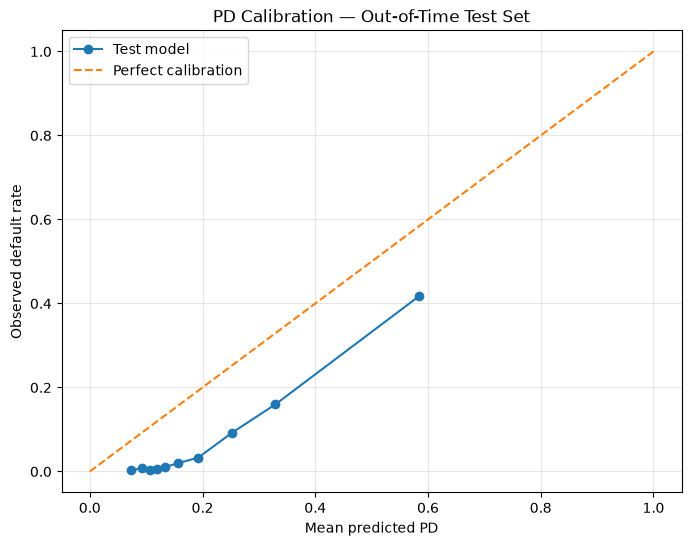

In [40]:
# ---------------------------------------------------------------------------
# Plot test-set calibration
# ---------------------------------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(
    calibration_curve_test["mean_predicted_pd"],
    calibration_curve_test["observed_default_rate"],
    marker="o",
    label="Test model",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration",
)

plt.xlabel("Mean predicted PD")
plt.ylabel("Observed default rate")
plt.title("PD Calibration — Out-of-Time Test Set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

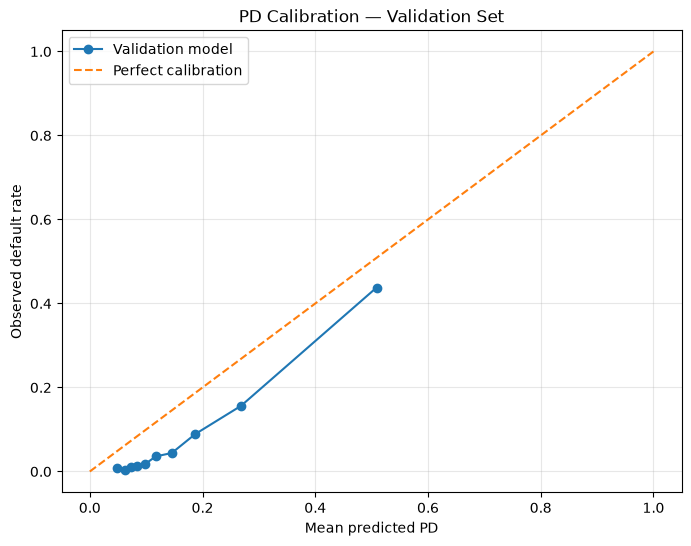

In [41]:
# ---------------------------------------------------------------------------
# Plot validation calibration
# ---------------------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    calibration_curve_validation["mean_predicted_pd"],
    calibration_curve_validation["observed_default_rate"],
    marker="o",
    label="Validation model",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration",
)

plt.xlabel("Mean predicted PD")
plt.ylabel("Observed default rate")
plt.title("PD Calibration — Validation Set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [42]:
# ---------------------------------------------------------------------------
# Prepare validation probabilities for calibration
# ---------------------------------------------------------------------------

from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression


validation_calibrator = LogisticRegression(
    max_iter=2_000,
    random_state=42,
)

validation_calibrator.fit(
    validation_pd.reshape(-1, 1),
    y_validation,
)

test_pd_platt = validation_calibrator.predict_proba(
    test_pd.reshape(-1, 1)
)[:, 1]

print(
    "Platt-style calibration mapping fitted on validation data."
)

Platt-style calibration mapping fitted on validation data.


In [43]:
# ---------------------------------------------------------------------------
# Split validation period for calibration development
# ---------------------------------------------------------------------------

calibration_fit_mask = (
    loan_portfolio["dataset_split"].eq("validation")
    & loan_portfolio["origination_year"].eq(2021)
)

calibration_eval_mask = (
    loan_portfolio["dataset_split"].eq("validation")
    & loan_portfolio["origination_year"].eq(2022)
)

X_calibration_fit = X.loc[calibration_fit_mask].copy()
y_calibration_fit = y.loc[calibration_fit_mask].copy()

X_calibration_eval = X.loc[calibration_eval_mask].copy()
y_calibration_eval = y.loc[calibration_eval_mask].copy()

# Transform using the already training-fitted preprocessor.
X_calibration_fit_processed = preprocessor.transform(
    X_calibration_fit
)

X_calibration_eval_processed = preprocessor.transform(
    X_calibration_eval
)

# Generate raw logistic PDs.
calibration_fit_pd = pd_model.predict_proba(
    X_calibration_fit_processed
)[:, 1]

calibration_eval_pd = pd_model.predict_proba(
    X_calibration_eval_processed
)[:, 1]

print(
    f"2021 calibration-fit observations: {len(y_calibration_fit):,}"
)
print(
    f"2022 calibration-evaluation observations: {len(y_calibration_eval):,}"
)

2021 calibration-fit observations: 5,564
2022 calibration-evaluation observations: 5,571


In [44]:
# ---------------------------------------------------------------------------
# Fit Platt calibration on 2021
# ---------------------------------------------------------------------------

platt_calibrator = LogisticRegression(
    max_iter=2_000,
    random_state=42,
)

platt_calibrator.fit(
    calibration_fit_pd.reshape(-1, 1),
    y_calibration_fit,
)

calibration_eval_pd_platt = (
    platt_calibrator.predict_proba(
        calibration_eval_pd.reshape(-1, 1)
    )[:, 1]
)

In [45]:
# ---------------------------------------------------------------------------
# Fit isotonic calibration on 2021
# ---------------------------------------------------------------------------

isotonic_calibrator = IsotonicRegression(
    y_min=0.0,
    y_max=1.0,
    out_of_bounds="clip",
)

isotonic_calibrator.fit(
    calibration_fit_pd,
    y_calibration_fit,
)

calibration_eval_pd_isotonic = (
    isotonic_calibrator.predict(
        calibration_eval_pd
    )
)

In [46]:
# ---------------------------------------------------------------------------
# Compare calibration methods on 2022
# ---------------------------------------------------------------------------

calibration_method_comparison = pd.DataFrame(
    {
        "method": [
            "raw_logistic",
            "platt",
            "isotonic",
        ],
        "brier_score": [
            brier_score_loss(
                y_calibration_eval,
                calibration_eval_pd,
            ),
            brier_score_loss(
                y_calibration_eval,
                calibration_eval_pd_platt,
            ),
            brier_score_loss(
                y_calibration_eval,
                calibration_eval_pd_isotonic,
            ),
        ],
        "roc_auc": [
            roc_auc_score(
                y_calibration_eval,
                calibration_eval_pd,
            ),
            roc_auc_score(
                y_calibration_eval,
                calibration_eval_pd_platt,
            ),
            roc_auc_score(
                y_calibration_eval,
                calibration_eval_pd_isotonic,
            ),
        ],
        "mean_predicted_pd": [
            calibration_eval_pd.mean(),
            calibration_eval_pd_platt.mean(),
            calibration_eval_pd_isotonic.mean(),
        ],
        "observed_default_rate": [
            y_calibration_eval.mean(),
            y_calibration_eval.mean(),
            y_calibration_eval.mean(),
        ],
    }
)

calibration_method_comparison["calibration_gap"] = (
    calibration_method_comparison["mean_predicted_pd"]
    - calibration_method_comparison["observed_default_rate"]
)

display(calibration_method_comparison)

,method,brier_score,roc_auc,mean_predicted_pd,observed_default_rate,calibration_gap
0,raw_logistic,0.065977,0.873541,0.175444,0.080775,0.094669
1,platt,0.058023,0.873541,0.107348,0.080775,0.026573
2,isotonic,0.059291,0.873209,0.115498,0.080775,0.034722


### Calibration Method Selection

Calibration methods were developed using 2021 data and evaluated on the
2022 calibration-evaluation period.

| Method | Brier Score | ROC-AUC | Mean Predicted PD | Observed Default Rate |
|---|---:|---:|---:|---:|
| Raw logistic | 0.06598 | 0.87354 | 17.54% | 8.08% |
| Platt | **0.05802** | **0.87354** | **10.73%** | 8.08% |
| Isotonic | 0.05929 | 0.87321 | 11.55% | 8.08% |

Platt calibration produced the lowest Brier score and smallest mean calibration
gap while preserving the model's discrimination.

**Decision:** Select Platt calibration for the final PD probability pipeline.

The 2023 test set remains untouched and will be used only for final evaluation.

In [47]:
# ---------------------------------------------------------------------------
# Apply selected Platt calibrator to untouched 2023 test set
# ---------------------------------------------------------------------------

test_pd_platt = platt_calibrator.predict_proba(
    test_pd.reshape(-1, 1)
)[:, 1]

final_test_metrics = pd.Series(
    {
        "raw_roc_auc": roc_auc_score(
            y_test,
            test_pd,
        ),
        "platt_roc_auc": roc_auc_score(
            y_test,
            test_pd_platt,
        ),
        "raw_brier": brier_score_loss(
            y_test,
            test_pd,
        ),
        "platt_brier": brier_score_loss(
            y_test,
            test_pd_platt,
        ),
        "observed_default_rate": y_test.mean(),
        "raw_mean_pd": test_pd.mean(),
        "platt_mean_pd": test_pd_platt.mean(),
        "raw_calibration_gap": (
            test_pd.mean() - y_test.mean()
        ),
        "platt_calibration_gap": (
            test_pd_platt.mean() - y_test.mean()
        ),
    },
    name="value",
)

display(final_test_metrics.to_frame())

,value
raw_roc_auc,0.888932
platt_roc_auc,0.888932
raw_brier,0.070487
platt_brier,0.058417
observed_default_rate,0.075372
raw_mean_pd,0.203945
platt_mean_pd,0.127130
raw_calibration_gap,0.128573
platt_calibration_gap,0.051758


# Baseline PD Model — Final Out-of-Time Result

The baseline Logistic Regression PD model was trained on 2015–2020
originations.

Calibration was developed using 2021 data and selected using 2022 data.
The 2023 cohort was retained as an untouched out-of-time test set.

### Final 2023 results

- Raw ROC-AUC: **0.88893**
- Platt-calibrated ROC-AUC: **0.88893**
- Raw Brier score: **0.07049**
- Platt-calibrated Brier score: **0.05842**
- Observed 2023 default rate: **7.54%**
- Raw mean predicted PD: **20.39%**
- Platt mean predicted PD: **12.71%**
- Raw calibration gap: **12.86 percentage points**
- Platt calibration gap: **5.18 percentage points**

### Interpretation

Platt calibration substantially improved probability accuracy while preserving
the model's ranking performance.

However, calibrated PDs remain above the observed 2023 default rate, indicating
residual temporal population shift.

**Conclusion:** The baseline model demonstrates strong out-of-time
discrimination but requires continued investigation of calibration stability
before it can be considered a robust production-style PD model.

In [48]:
# ---------------------------------------------------------------------------
# Inspect logistic-regression coefficients
# ---------------------------------------------------------------------------

feature_names = preprocessor.get_feature_names_out()

coefficients = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": pd_model.coef_[0],
    }
)

coefficients["absolute_coefficient"] = (
    coefficients["coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "absolute_coefficient",
    ascending=False,
)

display(coefficients.head(20))

,feature,coefficient,absolute_coefficient
30,categorical__initial_rating_CCC,1.549378,1.549378
26,categorical__initial_rating_AAA,-0.794087,0.794087
24,categorical__initial_rating_A,-0.640680,0.640680
25,categorical__initial_rating_AA,-0.637614,0.637614
29,categorical__initial_rating_BBB,-0.606262,0.606262
0,numeric__maturity_months,0.411593,0.411593
27,categorical__initial_rating_B,0.390822,0.390822
23,categorical__collateral_unsecured,-0.337681,0.337681
22,categorical__collateral_secured,-0.321584,0.321584
21,categorical__collateral_partially_secured,-0.312608,0.312608


In [50]:
# ---------------------------------------------------------------------------
# Convert coefficients to odds ratios
# ---------------------------------------------------------------------------
import numpy as np

coefficients["odds_ratio"] = (
    coefficients["coefficient"].apply(np.exp)
)

display(
    coefficients[
        [
            "feature",
            "coefficient",
            "odds_ratio",
        ]
    ].head(20)
)

,feature,coefficient,odds_ratio
30,categorical__initial_rating_CCC,1.549378,4.708540
26,categorical__initial_rating_AAA,-0.794087,0.451994
24,categorical__initial_rating_A,-0.640680,0.526934
25,categorical__initial_rating_AA,-0.637614,0.528552
29,categorical__initial_rating_BBB,-0.606262,0.545386
0,numeric__maturity_months,0.411593,1.509220
27,categorical__initial_rating_B,0.390822,1.478195
23,categorical__collateral_unsecured,-0.337681,0.713423
22,categorical__collateral_secured,-0.321584,0.725000
21,categorical__collateral_partially_secured,-0.312608,0.731536


In [51]:
# ---------------------------------------------------------------------------
# Strongest positive and negative coefficient effects
# ---------------------------------------------------------------------------

strongest_positive = (
    coefficients
    .sort_values("coefficient", ascending=False)
    .head(10)
)

strongest_negative = (
    coefficients
    .sort_values("coefficient", ascending=True)
    .head(10)
)

print("Strongest positive associations with default:")
display(
    strongest_positive[
        ["feature", "coefficient", "odds_ratio"]
    ]
)

print("\nStrongest negative associations with default:")
display(
    strongest_negative[
        ["feature", "coefficient", "odds_ratio"]
    ]
)

Strongest positive associations with default:


,feature,coefficient,odds_ratio
30,categorical__initial_rating_CCC,1.549378,4.708540
0,numeric__maturity_months,0.411593,1.509220
27,categorical__initial_rating_B,0.390822,1.478195
2,numeric__coupon_rate,0.189974,1.209219
5,numeric__debt_to_equity,-0.000900,0.999100
3,numeric__leverage,-0.010550,0.989505
8,categorical__sector_Financials,-0.019617,0.980574
1,numeric__credit_score,-0.046566,0.954501
7,categorical__sector_Energy,-0.047388,0.953717
4,numeric__interest_coverage,-0.049536,0.951671



Strongest negative associations with default:


,feature,coefficient,odds_ratio
26,categorical__initial_rating_AAA,-0.794087,0.451994
24,categorical__initial_rating_A,-0.640680,0.526934
25,categorical__initial_rating_AA,-0.637614,0.528552
29,categorical__initial_rating_BBB,-0.606262,0.545386
23,categorical__collateral_unsecured,-0.337681,0.713423
22,categorical__collateral_secured,-0.321584,0.725000
21,categorical__collateral_partially_secured,-0.312608,0.731536
16,categorical__loan_type_bond,-0.306477,0.736036
28,categorical__initial_rating_BB,-0.233429,0.791814
9,categorical__sector_Healthcare,-0.194954,0.822873


In [52]:
# ---------------------------------------------------------------------------
# Numeric-feature correlation
# ---------------------------------------------------------------------------

correlation_matrix = (
    loan_portfolio[
        NUMERIC_PD_FEATURES
    ]
    .corr()
)

display(correlation_matrix)

,maturity_months,credit_score,coupon_rate,leverage,interest_coverage,debt_to_equity
maturity_months,1.000000,0.004726,-0.008590,0.001744,0.002185,-0.000868
credit_score,0.004726,1.000000,-0.170225,-0.002871,0.005927,-0.000196
coupon_rate,-0.008590,-0.170225,1.000000,0.002853,0.004374,0.000549
leverage,0.001744,-0.002871,0.002853,1.000000,0.004084,0.000707
interest_coverage,0.002185,0.005927,0.004374,0.004084,1.000000,-0.003304
debt_to_equity,-0.000868,-0.000196,0.000549,0.000707,-0.003304,1.000000


In [53]:
# ---------------------------------------------------------------------------
# Identify highly correlated numeric feature pairs
# ---------------------------------------------------------------------------

correlation_pairs = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1,
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

correlation_pairs.columns = [
    "feature_1",
    "feature_2",
    "correlation",
]

correlation_pairs["absolute_correlation"] = (
    correlation_pairs["correlation"].abs()
)

display(
    correlation_pairs
    .sort_values(
        "absolute_correlation",
        ascending=False,
    )
    .head(15)
)

,feature_1,feature_2,correlation,absolute_correlation
8,credit_score,coupon_rate,-0.170225,0.170225
2,maturity_months,coupon_rate,-0.008590,0.008590
10,credit_score,interest_coverage,0.005927,0.005927
1,maturity_months,credit_score,0.004726,0.004726
16,coupon_rate,interest_coverage,0.004374,0.004374
22,leverage,interest_coverage,0.004084,0.004084
29,interest_coverage,debt_to_equity,-0.003304,0.003304
9,credit_score,leverage,-0.002871,0.002871
15,coupon_rate,leverage,0.002853,0.002853
4,maturity_months,interest_coverage,0.002185,0.002185


### Logistic Regression Interpretation — Baseline Findings

The logistic baseline learns several economically interpretable relationships.

**Credit rating:** Initial rating is the strongest categorical signal. Lower
credit-quality ratings, particularly B and CCC, are associated with higher
modeled odds of default relative to the reference rating.

**Maturity:** `maturity_months` has a positive coefficient and is associated
with higher modeled default odds. Because numeric features were standardized,
the odds ratio represents the effect of a one-standard-deviation increase.

**Credit score:** The coefficient is negative, indicating that higher credit
scores are associated with lower modeled default odds.

**Multicollinearity:** Pairwise correlations among numeric predictors are
generally weak. The largest absolute correlation is approximately 0.17 between
credit score and coupon rate, so there is no obvious severe pairwise
multicollinearity issue.

**Interpretation caution:** Logistic coefficients represent conditional
associations, not causal effects. Categorical coefficients are interpreted
relative to the encoder's reference category.

In [54]:
# ---------------------------------------------------------------------------
# Identify categorical reference categories
# ---------------------------------------------------------------------------

categorical_encoder = (
    preprocessor
    .named_transformers_["categorical"]
    .named_steps["encoder"]
)

for feature, categories in zip(
    CATEGORICAL_PD_FEATURES,
    categorical_encoder.categories_,
):
    print(f"{feature}:")
    print(f"  categories = {list(categories)}")
    print(f"  reference  = {categories[0]}")
    print()

sector:
  categories = ['Consumer', 'Energy', 'Financials', 'Healthcare', 'Industrials', 'Real_Estate', 'Retail', 'Technology', 'Telecom', 'Utilities']
  reference  = Consumer

loan_type:
  categories = ['bond', 'lease', 'mortgage', 'revolving', 'term_loan']
  reference  = bond

collateral:
  categories = ['partially_secured', 'secured', 'unsecured']
  reference  = partially_secured

initial_rating:
  categories = ['A', 'AA', 'AAA', 'B', 'BB', 'BBB', 'CCC']
  reference  = A



In [55]:
# ---------------------------------------------------------------------------
# Nonlinear benchmark model
# ---------------------------------------------------------------------------

from sklearn.ensemble import HistGradientBoostingClassifier

In [56]:
# ---------------------------------------------------------------------------
# Train nonlinear PD benchmark
# ---------------------------------------------------------------------------

gb_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=15,
    min_samples_leaf=50,
    l2_regularization=1.0,
    random_state=42,
)

gb_model.fit(
    X_train_processed,
    y_train,
)

print("Nonlinear PD benchmark trained.")

Nonlinear PD benchmark trained.


In [57]:
# ---------------------------------------------------------------------------
# Generate nonlinear PD predictions
# ---------------------------------------------------------------------------

gb_train_pd = gb_model.predict_proba(
    X_train_processed
)[:, 1]

gb_validation_pd = gb_model.predict_proba(
    X_validation_processed
)[:, 1]

gb_test_pd = gb_model.predict_proba(
    X_test_processed
)[:, 1]

In [58]:
# ---------------------------------------------------------------------------
# Compare discrimination and calibration
# ---------------------------------------------------------------------------

model_comparison = pd.DataFrame(
    {
        "model": [
            "logistic_raw",
            "gradient_boosting",
        ],
        "train_roc_auc": [
            roc_auc_score(y_train, train_pd),
            roc_auc_score(y_train, gb_train_pd),
        ],
        "validation_roc_auc": [
            roc_auc_score(y_validation, validation_pd),
            roc_auc_score(y_validation, gb_validation_pd),
        ],
        "test_roc_auc": [
            roc_auc_score(y_test, test_pd),
            roc_auc_score(y_test, gb_test_pd),
        ],
        "validation_brier": [
            brier_score_loss(y_validation, validation_pd),
            brier_score_loss(y_validation, gb_validation_pd),
        ],
        "test_brier": [
            brier_score_loss(y_test, test_pd),
            brier_score_loss(y_test, gb_test_pd),
        ],
    }
)

display(model_comparison)

,model,train_roc_auc,validation_roc_auc,test_roc_auc,validation_brier,test_brier
0,logistic_raw,0.736855,0.871796,0.888932,0.063608,0.070487
1,gradient_boosting,0.765238,0.862659,0.878311,0.061589,0.063942


In [59]:
# ---------------------------------------------------------------------------
# Compare out-of-time PD levels
# ---------------------------------------------------------------------------

pd_level_comparison = pd.DataFrame(
    {
        "model": [
            "logistic_raw",
            "logistic_platt",
            "gradient_boosting",
        ],
        "mean_test_pd": [
            test_pd.mean(),
            test_pd_platt.mean(),
            gb_test_pd.mean(),
        ],
        "observed_test_default_rate": [
            y_test.mean(),
            y_test.mean(),
            y_test.mean(),
        ],
    }
)

pd_level_comparison["calibration_gap"] = (
    pd_level_comparison["mean_test_pd"]
    - pd_level_comparison["observed_test_default_rate"]
)

display(pd_level_comparison)

,model,mean_test_pd,observed_test_default_rate,calibration_gap
0,logistic_raw,0.203945,0.075372,0.128573
1,logistic_platt,0.127130,0.075372,0.051758
2,gradient_boosting,0.177030,0.075372,0.101657


### Nonlinear Challenger Model — Finding

A HistGradientBoosting model was evaluated using the same temporal splits and
feature set as the Logistic Regression baseline.

| Model | Test ROC-AUC | Test Brier |
|---|---:|---:|
| Logistic Regression | **0.8889** | 0.0705 |
| Gradient Boosting | 0.8783 | **0.0639** |

The gradient-boosting model achieved higher training discrimination but lower
out-of-time ROC-AUC than Logistic Regression. Its uncalibrated test PD level
also remained substantially above the observed 2023 default rate.

The Platt-calibrated Logistic Regression remained the strongest overall
baseline for probability estimation, with a test Brier score of **0.0584** and
a calibration gap of **5.18 percentage points**.

**Decision:** Retain Logistic Regression + Platt calibration as the primary PD
model. Retain Gradient Boosting as a challenger benchmark.

In [60]:
# ---------------------------------------------------------------------------
# Create validation PD risk bands
# ---------------------------------------------------------------------------

validation_risk_data = pd.DataFrame(
    {
        "observed_default": y_validation.values,
        "predicted_pd": validation_pd.reshape(-1),
    }
)

validation_risk_data["risk_band"] = pd.qcut(
    validation_risk_data["predicted_pd"],
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High",
    ],
    duplicates="drop",
)

validation_band_summary = (
    validation_risk_data
    .groupby("risk_band", observed=False)
    .agg(
        loans=("observed_default", "size"),
        defaults=("observed_default", "sum"),
        average_pd=("predicted_pd", "mean"),
        observed_default_rate=("observed_default", "mean"),
    )
)

validation_band_summary["observed_default_rate_pct"] = (
    validation_band_summary["observed_default_rate"] * 100
)

display(validation_band_summary)

,loans,defaults,average_pd,observed_default_rate,observed_default_rate_pct
risk_band,,,,,
Very Low,2227,12,0.054872,0.005388,0.538841
Low,2227,25,0.078304,0.011226,1.122586
Medium,2227,60,0.107715,0.026942,2.694207
High,2227,148,0.166163,0.066457,6.645712
Very High,2227,662,0.388654,0.297261,29.726089


In [133]:
# ---------------------------------------------------------------------------
# Extract validation risk-band thresholds
# ---------------------------------------------------------------------------

risk_band_edges = (
    validation_risk_data["predicted_pd"]
    .quantile([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    .to_numpy()
)

print("Validation PD band thresholds:")
print(risk_band_edges)

Validation PD band thresholds:
[0.02742287 0.06775228 0.09014777 0.12828781 0.21376508 0.8465785 ]


In [233]:
# ---------------------------------------------------------------------------
# Apply validation-derived risk bands to test PDs
# ---------------------------------------------------------------------------

risk_band_edges = (
    validation_risk_data["predicted_pd"]
    .quantile([0.2, 0.4, 0.6, 0.8])
    .to_numpy()
)

test_risk_data["risk_band"] = pd.cut(
    test_risk_data["predicted_pd"],
    bins=[
        float("-inf"),
        risk_band_edges[0],
        risk_band_edges[1],
        risk_band_edges[2],
        risk_band_edges[3],
        float("inf"),
    ],
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High",
    ],
    include_lowest=True,
)

display(
    test_risk_data["risk_band"]
    .value_counts(dropna=False)
)

risk_band
Very Low     3411
Very High     723
High          503
Medium        450
Low           419
Name: count, dtype: int64

In [234]:
# ---------------------------------------------------------------------------
# Validate monotonicity of observed default rates
# ---------------------------------------------------------------------------

band_order = [
    "Very Low",
    "Low",
    "Medium",
    "High",
    "Very High",
]

test_default_rates = (
    test_band_summary
    .reindex(band_order)["observed_default_rate"]
    .dropna()
)

monotonic_risk = (
    test_default_rates.diff().dropna() >= 0
).all()

print(
    "Observed default rate is monotonic across risk bands:",
    monotonic_risk,
)

display(
    test_band_summary.reindex(band_order)
)

Observed default rate is monotonic across risk bands: True


,loans,defaults,average_pd,observed_default_rate,observed_default_rate_pct
risk_band,,,,,
Very Low,3356,30,0.043456,0.008939,0.893921
Low,419,15,0.076601,0.035800,3.579952
Medium,450,47,0.109988,0.104444,10.444444
High,503,61,0.159887,0.121272,12.127237
Very High,669,223,0.511703,0.333333,33.333333


### Out-of-Time PD Risk Bands

Validation-derived PD risk-band thresholds were applied unchanged to the
2023 out-of-time test population.

| Risk Band | Average Predicted PD | Observed Default Rate |
|---|---:|---:|
| Very Low | 4.35% | 0.89% |
| Low | 7.66% | 3.58% |
| Medium | 11.00% | 10.44% |
| High | 15.99% | 12.13% |
| Very High | 51.17% | 33.33% |

Observed default rates were strictly monotonic across the five bands.

The observed default rate increased from **0.89% in the Very Low band** to
**33.33% in the Very High band**, demonstrating strong out-of-time risk
segmentation.

However, predicted PD remains above observed default rates in the higher-risk
bands, indicating residual probability overestimation after Platt calibration.

**Conclusion:** The model provides strong risk ranking and monotonic
segmentation, while further calibration/stability analysis remains warranted.

In [235]:
# ---------------------------------------------------------------------------
# KS statistic for out-of-time PD ranking
# ---------------------------------------------------------------------------

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    test_pd_platt,
)

ks_values = tpr - fpr

ks_index = ks_values.argmax()

ks_statistic = ks_values[ks_index]
ks_threshold = thresholds[ks_index]

ks_summary = pd.Series(
    {
        "ks_statistic": ks_statistic,
        "pd_threshold_at_max_ks": ks_threshold,
    },
    name="value",
)

display(ks_summary.to_frame())

,value
ks_statistic,0.640234
pd_threshold_at_max_ks,0.094682


In [236]:
# ---------------------------------------------------------------------------
# Test-set PD separation table
# ---------------------------------------------------------------------------

ks_data = pd.DataFrame(
    {
        "observed_default": y_test.values,
        "predicted_pd": test_pd_platt,
    }
)

ks_data = ks_data.sort_values(
    "predicted_pd",
    ascending=True,
).reset_index(drop=True)

ks_data["non_default"] = (
    1 - ks_data["observed_default"]
)

ks_data["cumulative_defaults"] = (
    ks_data["observed_default"].cumsum()
)

ks_data["cumulative_non_defaults"] = (
    ks_data["non_default"].cumsum()
)

total_defaults = ks_data["observed_default"].sum()
total_non_defaults = ks_data["non_default"].sum()

ks_data["cum_default_rate"] = (
    ks_data["cumulative_defaults"]
    / total_defaults
)

ks_data["cum_non_default_rate"] = (
    ks_data["cumulative_non_defaults"]
    / total_non_defaults
)

ks_data["ks"] = (
    ks_data["cum_non_default_rate"]
    - ks_data["cum_default_rate"]
).abs()

display(
    ks_data[
        [
            "predicted_pd",
            "observed_default",
            "cum_default_rate",
            "cum_non_default_rate",
            "ks",
        ]
    ].tail(10)
)

,predicted_pd,observed_default,cum_default_rate,cum_non_default_rate,ks
5496,0.924886,1,0.980723,0.999804,0.019081
5497,0.926080,1,0.983133,0.999804,0.016671
5498,0.928585,1,0.985542,0.999804,0.014261
5499,0.929033,1,0.987952,0.999804,0.011852
5500,0.930218,1,0.990361,0.999804,0.009442
5501,0.930753,1,0.992771,0.999804,0.007032
5502,0.931603,1,0.995181,0.999804,0.004623
5503,0.932960,0,0.995181,1.000000,0.004819
5504,0.934021,1,0.997590,1.000000,0.002410
5505,0.935140,1,1.000000,1.000000,0.000000


In [237]:
# ---------------------------------------------------------------------------
# Confirm empirical KS maximum
# ---------------------------------------------------------------------------

empirical_ks = ks_data["ks"].max()

print(
    f"Empirical KS statistic: {empirical_ks:.4f}"
)

Empirical KS statistic: 0.6402


### Out-of-Time KS Separation

The Platt-calibrated PD model achieved an empirical KS statistic of **0.6402**
on the untouched 2023 test population.

**Interpretation:** The model provides strong separation between defaulted and
non-defaulted loans across the predicted-PD distribution.

The KS result is consistent with the model's ROC-AUC of **0.8889** and the
monotonic risk-band performance observed on the same out-of-time population.

**Important:** Strong discrimination does not imply perfect probability
calibration. The model continues to overpredict absolute default probabilities
under the observed temporal population shift.

In [238]:
# ---------------------------------------------------------------------------
# Prepare defaulted-loan population for LGD modelling
# ---------------------------------------------------------------------------

LGD_FEATURES = [
    "maturity_months",
    "sector",
    "loan_type",
    "collateral",
    "initial_rating",
    "credit_score",
    "coupon_rate",
    "leverage",
    "interest_coverage",
    "debt_to_equity",
]

LGD_TARGET = "lgd"

defaulted_loans = loan_portfolio.loc[
    loan_portfolio["defaulted"].eq(1)
].copy()

print(
    f"Defaulted loans available for LGD modelling: "
    f"{len(defaulted_loans):,}"
)

Defaulted loans available for LGD modelling: 6,950


In [239]:
# ---------------------------------------------------------------------------
# Create temporal LGD modelling split
# ---------------------------------------------------------------------------

defaulted_loans["origination_date"] = pd.to_datetime(
    defaulted_loans["origination_date"],
    errors="coerce",
)

defaulted_loans["origination_year"] = (
    defaulted_loans["origination_date"].dt.year
)

defaulted_loans["lgd_split"] = "test"

defaulted_loans.loc[
    defaulted_loans["origination_year"] <= 2020,
    "lgd_split",
] = "train"

defaulted_loans.loc[
    defaulted_loans["origination_year"].between(
        2021,
        2022,
    ),
    "lgd_split",
] = "validation"

lgd_split_summary = (
    defaulted_loans
    .groupby("lgd_split")
    .agg(
        loans=("loan_id", "count"),
        mean_lgd=("lgd", "mean"),
        median_lgd=("lgd", "median"),
        min_lgd=("lgd", "min"),
        max_lgd=("lgd", "max"),
        earliest_origination=("origination_date", "min"),
        latest_origination=("origination_date", "max"),
    )
)

display(lgd_split_summary)

,loans,mean_lgd,median_lgd,min_lgd,max_lgd,earliest_origination,latest_origination
lgd_split,,,,,,,
test,415,0.547596,0.5319,0.1965,0.98,2023-01-01,2023-12-01
train,5628,0.544145,0.5439,0.1455,0.98,2015-01-01,2020-12-01
validation,907,0.552474,0.5491,0.1422,0.98,2021-01-01,2022-12-01


In [240]:
# ---------------------------------------------------------------------------
# Inspect LGD distribution by origination year
# ---------------------------------------------------------------------------

lgd_by_year = (
    defaulted_loans
    .groupby("origination_year")
    .agg(
        defaults=("loan_id", "count"),
        mean_lgd=("lgd", "mean"),
        median_lgd=("lgd", "median"),
    )
)

display(lgd_by_year)

,defaults,mean_lgd,median_lgd
origination_year,,,
2015,712,0.545018,0.54175
2016,854,0.548146,0.55050
2017,1047,0.545774,0.54440
2018,1092,0.537962,0.53640
2019,1195,0.542523,0.54390
2020,728,0.548188,0.55095
2021,457,0.547636,0.54550
2022,450,0.557387,0.55455
2023,415,0.547596,0.53190


In [241]:
# ---------------------------------------------------------------------------
# Build LGD modelling matrices
# ---------------------------------------------------------------------------

X_lgd = defaulted_loans[LGD_FEATURES].copy()
y_lgd = defaulted_loans[LGD_TARGET].copy()

train_lgd_mask = defaulted_loans["lgd_split"].eq("train")
validation_lgd_mask = defaulted_loans["lgd_split"].eq("validation")
test_lgd_mask = defaulted_loans["lgd_split"].eq("test")

X_lgd_train = X_lgd.loc[train_lgd_mask].copy()
y_lgd_train = y_lgd.loc[train_lgd_mask].copy()

X_lgd_validation = X_lgd.loc[validation_lgd_mask].copy()
y_lgd_validation = y_lgd.loc[validation_lgd_mask].copy()

X_lgd_test = X_lgd.loc[test_lgd_mask].copy()
y_lgd_test = y_lgd.loc[test_lgd_mask].copy()

print("LGD training:", X_lgd_train.shape, y_lgd_train.shape)
print("LGD validation:", X_lgd_validation.shape, y_lgd_validation.shape)
print("LGD test:", X_lgd_test.shape, y_lgd_test.shape)

LGD training: (5628, 10) (5628,)
LGD validation: (907, 10) (907,)
LGD test: (415, 10) (415,)


In [242]:
# ---------------------------------------------------------------------------
# LGD feature-type definitions
# ---------------------------------------------------------------------------

NUMERIC_LGD_FEATURES = [
    "maturity_months",
    "credit_score",
    "coupon_rate",
    "leverage",
    "interest_coverage",
    "debt_to_equity",
]

CATEGORICAL_LGD_FEATURES = [
    "sector",
    "loan_type",
    "collateral",
    "initial_rating",
]

In [243]:
# ---------------------------------------------------------------------------
# LGD preprocessing pipeline
# ---------------------------------------------------------------------------

lgd_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

lgd_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

lgd_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            lgd_numeric_pipeline,
            NUMERIC_LGD_FEATURES,
        ),
        (
            "categorical",
            lgd_categorical_pipeline,
            CATEGORICAL_LGD_FEATURES,
        ),
    ],
    remainder="drop",
)

lgd_preprocessor.fit(X_lgd_train)

X_lgd_train_processed = lgd_preprocessor.transform(
    X_lgd_train
)

X_lgd_validation_processed = lgd_preprocessor.transform(
    X_lgd_validation
)

X_lgd_test_processed = lgd_preprocessor.transform(
    X_lgd_test
)

print(
    "LGD preprocessing completed using training data only."
)

LGD preprocessing completed using training data only.


In [244]:
# ---------------------------------------------------------------------------
# LGD baseline models and evaluation metrics
# ---------------------------------------------------------------------------

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import numpy as np

In [245]:
# ---------------------------------------------------------------------------
# Train mean-LGD baseline
# ---------------------------------------------------------------------------

lgd_baseline = DummyRegressor(
    strategy="mean",
)

lgd_baseline.fit(
    X_lgd_train_processed,
    y_lgd_train,
)

lgd_train_baseline = lgd_baseline.predict(
    X_lgd_train_processed
)

lgd_validation_baseline = lgd_baseline.predict(
    X_lgd_validation_processed
)

lgd_test_baseline = lgd_baseline.predict(
    X_lgd_test_processed
)

In [246]:
# ---------------------------------------------------------------------------
# Train nonlinear LGD model
# ---------------------------------------------------------------------------

lgd_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=15,
    min_samples_leaf=30,
    l2_regularization=1.0,
    loss="squared_error",
    random_state=42,
)

lgd_model.fit(
    X_lgd_train_processed,
    y_lgd_train,
)

print("LGD gradient-boosting model trained.")

LGD gradient-boosting model trained.


In [247]:
# ---------------------------------------------------------------------------
# Generate LGD predictions
# ---------------------------------------------------------------------------

lgd_train_pred = lgd_model.predict(
    X_lgd_train_processed
)

lgd_validation_pred = lgd_model.predict(
    X_lgd_validation_processed
)

lgd_test_pred = lgd_model.predict(
    X_lgd_test_processed
)

# Constrain predicted LGD to the valid [0, 1] range.
lgd_train_pred = np.clip(
    lgd_train_pred,
    0.0,
    1.0,
)

lgd_validation_pred = np.clip(
    lgd_validation_pred,
    0.0,
    1.0,
)

lgd_test_pred = np.clip(
    lgd_test_pred,
    0.0,
    1.0,
)

In [248]:
# ---------------------------------------------------------------------------
# Evaluate LGD model
# ---------------------------------------------------------------------------

def regression_metrics(
    actual: pd.Series,
    predicted: np.ndarray,
) -> dict[str, float]:
    """Calculate standard LGD regression metrics."""
    
    return {
        "mae": mean_absolute_error(actual, predicted),
        "rmse": np.sqrt(
            mean_squared_error(actual, predicted)
        ),
        "r2": r2_score(actual, predicted),
    }


lgd_model_comparison = pd.DataFrame(
    [
        {
            "model": "mean_baseline",
            "dataset": "validation",
            **regression_metrics(
                y_lgd_validation,
                lgd_validation_baseline,
            ),
        },
        {
            "model": "gradient_boosting",
            "dataset": "validation",
            **regression_metrics(
                y_lgd_validation,
                lgd_validation_pred,
            ),
        },
        {
            "model": "mean_baseline",
            "dataset": "test",
            **regression_metrics(
                y_lgd_test,
                lgd_test_baseline,
            ),
        },
        {
            "model": "gradient_boosting",
            "dataset": "test",
            **regression_metrics(
                y_lgd_test,
                lgd_test_pred,
            ),
        },
    ]
)

display(lgd_model_comparison)

,model,dataset,mae,rmse,r2
0,mean_baseline,validation,0.118296,0.145938,-0.003268
1,gradient_boosting,validation,0.080010,0.098261,0.545172
2,mean_baseline,test,0.121095,0.146828,-0.000553
3,gradient_boosting,test,0.080231,0.099040,0.544757


In [249]:
# ---------------------------------------------------------------------------
# Validate predicted LGD range
# ---------------------------------------------------------------------------

lgd_prediction_range = pd.DataFrame(
    {
        "dataset": [
            "train",
            "validation",
            "test",
        ],
        "minimum_prediction": [
            lgd_train_pred.min(),
            lgd_validation_pred.min(),
            lgd_test_pred.min(),
        ],
        "maximum_prediction": [
            lgd_train_pred.max(),
            lgd_validation_pred.max(),
            lgd_test_pred.max(),
        ],
        "mean_prediction": [
            lgd_train_pred.mean(),
            lgd_validation_pred.mean(),
            lgd_test_pred.mean(),
        ],
    }
)

display(lgd_prediction_range)

,dataset,minimum_prediction,maximum_prediction,mean_prediction
0,train,0.308564,0.813959,0.544144
1,validation,0.324345,0.809376,0.552263
2,test,0.320799,0.783562,0.542680


### LGD Model — Out-of-Time Finding

The Gradient Boosting LGD model was compared against a mean-LGD baseline using
the same temporal modelling framework.

On the 2023 out-of-time test population:

- Mean baseline MAE: **0.1211**
- Gradient Boosting MAE: **0.0802**
- Mean baseline R²: approximately **0**
- Gradient Boosting R²: **0.5448**

The LGD model therefore materially improves on the baseline and explains
approximately **54.5% of the observed LGD variation** in the out-of-time test.

The validation and test results are highly stable:

- Validation MAE: **0.0800**
- Test MAE: **0.0802**
- Validation R²: **0.5452**
- Test R²: **0.5448**

The model's test predictions remain within the valid [0,1] LGD range.

**Conclusion:** The synthetic portfolio contains meaningful and temporally stable
structure for modelling loss severity after default.

In [250]:
from sklearn.inspection import permutation_importance

lgd_feature_names = (
    lgd_preprocessor.get_feature_names_out()
)

lgd_permutation = permutation_importance(
    lgd_model,
    X_lgd_test_processed,
    y_lgd_test,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=42,
)

lgd_feature_importance = pd.DataFrame(
    {
        "feature": lgd_feature_names,
        "importance_mean": lgd_permutation.importances_mean,
        "importance_std": lgd_permutation.importances_std,
    }
).sort_values(
    "importance_mean",
    ascending=False,
)

display(lgd_feature_importance.head(20))

,feature,importance_mean,importance_std
22,categorical__collateral_secured,0.050622,0.002749
13,categorical__sector_Technology,0.007355,0.000792
12,categorical__sector_Retail,0.005529,0.001235
11,categorical__sector_Real_Estate,0.004184,0.000668
6,categorical__sector_Consumer,0.002724,0.000842
15,categorical__sector_Utilities,0.001838,0.000570
21,categorical__collateral_partially_secured,0.001532,0.000777
23,categorical__collateral_unsecured,0.001020,0.000420
14,categorical__sector_Telecom,0.000736,0.000143
7,categorical__sector_Energy,0.000512,0.000406


In [251]:
# ---------------------------------------------------------------------------
# LGD model permutation importance
# ---------------------------------------------------------------------------

from sklearn.inspection import permutation_importance

lgd_feature_names = (
    lgd_preprocessor.get_feature_names_out()
)

lgd_permutation = permutation_importance(
    lgd_model,
    X_lgd_test_processed,
    y_lgd_test,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=42,
)

lgd_feature_importance = (
    pd.DataFrame(
        {
            "feature": lgd_feature_names,
            "importance_mean": (
                lgd_permutation.importances_mean
            ),
            "importance_std": (
                lgd_permutation.importances_std
            ),
        }
    )
    .sort_values(
        "importance_mean",
        ascending=False,
    )
)

display(
    lgd_feature_importance.head(20)
)

,feature,importance_mean,importance_std
22,categorical__collateral_secured,0.050622,0.002749
13,categorical__sector_Technology,0.007355,0.000792
12,categorical__sector_Retail,0.005529,0.001235
11,categorical__sector_Real_Estate,0.004184,0.000668
6,categorical__sector_Consumer,0.002724,0.000842
15,categorical__sector_Utilities,0.001838,0.000570
21,categorical__collateral_partially_secured,0.001532,0.000777
23,categorical__collateral_unsecured,0.001020,0.000420
14,categorical__sector_Telecom,0.000736,0.000143
7,categorical__sector_Energy,0.000512,0.000406


In [252]:
# ---------------------------------------------------------------------------
# Map transformed LGD features back to source variables
# ---------------------------------------------------------------------------

def map_lgd_feature_to_source(feature_name: str) -> str:
    """Map transformed feature names to their original variables."""

    feature_name = (
        feature_name
        .replace("numeric__", "")
        .replace("categorical__", "")
    )

    for variable in (
        NUMERIC_LGD_FEATURES
        + CATEGORICAL_LGD_FEATURES
    ):
        if feature_name == variable:
            return variable

        if feature_name.startswith(
            f"{variable}_"
        ):
            return variable

    return feature_name

In [253]:
# ---------------------------------------------------------------------------
# Aggregate LGD importance by original business variable
# ---------------------------------------------------------------------------

lgd_feature_importance["source_variable"] = (
    lgd_feature_importance["feature"]
    .map(map_lgd_feature_to_source)
)

lgd_variable_importance = (
    lgd_feature_importance
    .groupby("source_variable", as_index=False)
    .agg(
        importance_mean=("importance_mean", "sum"),
        importance_std=("importance_std", "mean"),
    )
    .sort_values(
        "importance_mean",
        ascending=False,
    )
)

display(lgd_variable_importance)

,source_variable,importance_mean,importance_std
0,collateral,0.053174,0.001316
9,sector,0.022765,0.000536
1,coupon_rate,0.000347,0.000226
4,initial_rating,0.000039,0.000019
5,interest_coverage,-0.000137,0.000507
7,loan_type,-0.000211,0.000040
6,leverage,-0.000218,0.000410
8,maturity_months,-0.000255,0.000319
3,debt_to_equity,-0.000505,0.000355
2,credit_score,-0.000569,0.000391


In [254]:
# ---------------------------------------------------------------------------
# LGD predictions by collateral
# ---------------------------------------------------------------------------

lgd_test_results = X_lgd_test.copy()

lgd_test_results["actual_lgd"] = (
    y_lgd_test.to_numpy()
)

lgd_test_results["predicted_lgd"] = (
    lgd_test_pred
)

lgd_collateral_summary = (
    lgd_test_results
    .groupby("collateral")
    .agg(
        loans=("actual_lgd", "size"),
        actual_lgd=("actual_lgd", "mean"),
        predicted_lgd=("predicted_lgd", "mean"),
    )
)

lgd_collateral_summary["prediction_error"] = (
    lgd_collateral_summary["predicted_lgd"]
    - lgd_collateral_summary["actual_lgd"]
)

display(lgd_collateral_summary)

,loans,actual_lgd,predicted_lgd,prediction_error
collateral,,,,
partially_secured,77,0.586253,0.568910,-0.017344
secured,193,0.452522,0.456133,0.003611
unsecured,145,0.653616,0.643947,-0.009668


In [255]:
# ---------------------------------------------------------------------------
# Validate predicted LGD ordering by collateral
# ---------------------------------------------------------------------------

collateral_order = [
    "secured",
    "partially_secured",
    "unsecured",
]

predicted_lgd_by_collateral = (
    lgd_collateral_summary
    .reindex(collateral_order)
    ["predicted_lgd"]
)

print(
    "Predicted LGD increases from secured to unsecured:",
    predicted_lgd_by_collateral.is_monotonic_increasing,
)

display(
    predicted_lgd_by_collateral.to_frame(
        "predicted_lgd"
    )
)

Predicted LGD increases from secured to unsecured: True


,predicted_lgd
collateral,
secured,0.456133
partially_secured,0.568910
unsecured,0.643947


In [256]:
lgd_test_results = X_lgd_test.copy()

lgd_test_results["actual_lgd"] = y_lgd_test.to_numpy()
lgd_test_results["predicted_lgd"] = lgd_test_pred

lgd_collateral_summary = (
    lgd_test_results
    .groupby("collateral")
    .agg(
        loans=("actual_lgd", "size"),
        actual_lgd=("actual_lgd", "mean"),
        predicted_lgd=("predicted_lgd", "mean"),
    )
)

lgd_collateral_summary["prediction_error"] = (
    lgd_collateral_summary["predicted_lgd"]
    - lgd_collateral_summary["actual_lgd"]
)

display(lgd_collateral_summary)

,loans,actual_lgd,predicted_lgd,prediction_error
collateral,,,,
partially_secured,77,0.586253,0.568910,-0.017344
secured,193,0.452522,0.456133,0.003611
unsecured,145,0.653616,0.643947,-0.009668


In [257]:
collateral_order = [
    "secured",
    "partially_secured",
    "unsecured",
]

predicted_lgd_by_collateral = (
    lgd_collateral_summary
    .reindex(collateral_order)["predicted_lgd"]
)

print(
    "Predicted LGD increases from secured to unsecured:",
    predicted_lgd_by_collateral.is_monotonic_increasing,
)

display(
    predicted_lgd_by_collateral.to_frame("predicted_lgd")
)

Predicted LGD increases from secured to unsecured: True


,predicted_lgd
collateral,
secured,0.456133
partially_secured,0.568910
unsecured,0.643947


In [258]:
# ---------------------------------------------------------------------------
# Prepare 2023 out-of-time population for ECL
# ---------------------------------------------------------------------------

test_portfolio = loan_portfolio.loc[
    loan_portfolio["dataset_split"].eq("test")
].copy()

print(
    f"2023 ECL population: {len(test_portfolio):,} loans"
)

2023 ECL population: 5,506 loans


In [259]:
# ---------------------------------------------------------------------------
# Predict LGD for all 2023 test loans
# ---------------------------------------------------------------------------

X_test_lgd_all = test_portfolio[
    LGD_FEATURES
].copy()

X_test_lgd_all_processed = lgd_preprocessor.transform(
    X_test_lgd_all
)

test_lgd_all = lgd_model.predict(
    X_test_lgd_all_processed
)

test_lgd_all = np.clip(
    test_lgd_all,
    0.0,
    1.0,
)

print(
    f"Predicted LGD range: "
    f"{test_lgd_all.min():.2%} → "
    f"{test_lgd_all.max():.2%}"
)

Predicted LGD range: 30.50% → 81.05%


In [260]:
# ---------------------------------------------------------------------------
# Build 2023 ECL calculation
# ---------------------------------------------------------------------------

ecl_test = test_portfolio[
    [
        "loan_id",
        "defaulted",
        "ead",
    ]
].copy()

ecl_test["pd_predicted"] = test_pd_platt
ecl_test["lgd_predicted"] = test_lgd_all

ecl_test["ecl_predicted"] = (
    ecl_test["pd_predicted"]
    * ecl_test["lgd_predicted"]
    * ecl_test["ead"]
)

display(
    ecl_test.head(10)
)

,loan_id,defaulted,ead,pd_predicted,lgd_predicted,ecl_predicted
2,L000003,0,4327864.12,0.032306,0.342996,4.795707e+04
5,L000006,0,76645.49,0.113972,0.455710,3.980819e+03
14,L000015,0,9141471.35,0.048921,0.567841,2.539460e+05
15,L000016,0,712549.16,0.372420,0.463702,1.230513e+05
23,L000024,0,4576527.65,0.718182,0.582849,1.915697e+06
27,L000028,0,1195035.99,0.077755,0.445817,4.142542e+04
48,L000049,1,806712.79,0.127352,0.704042,7.233094e+04
55,L000056,0,849396.49,0.035321,0.494170,1.482585e+04
61,L000062,0,121582.51,0.126404,0.498782,7.665521e+03
71,L000072,1,2536560.22,0.715881,0.449166,8.156304e+05


In [261]:
# ---------------------------------------------------------------------------
# ECL calculation validation
# ---------------------------------------------------------------------------

ecl_component_summary = pd.DataFrame(
    {
        "metric": [
            "Mean predicted PD",
            "Mean predicted LGD",
            "Mean EAD",
            "Total EAD",
            "Total predicted ECL",
        ],
        "value": [
            ecl_test["pd_predicted"].mean(),
            ecl_test["lgd_predicted"].mean(),
            ecl_test["ead"].mean(),
            ecl_test["ead"].sum(),
            ecl_test["ecl_predicted"].sum(),
        ],
    }
)

display(ecl_component_summary)

,metric,value
0,Mean predicted PD,1.271304e-01
1,Mean predicted LGD,5.432453e-01
2,Mean EAD,3.329441e+06
3,Total EAD,1.833190e+10
4,Total predicted ECL,1.206036e+09


In [262]:
# ---------------------------------------------------------------------------
# Portfolio ECL rate
# ---------------------------------------------------------------------------

total_ecl = ecl_test["ecl_predicted"].sum()
total_ead = ecl_test["ead"].sum()

portfolio_ecl_rate = (
    total_ecl / total_ead
)

print(
    f"2023 predicted portfolio ECL: "
    f"{total_ecl:,.2f}"
)

print(
    f"2023 predicted ECL rate: "
    f"{portfolio_ecl_rate:.4%}"
)

2023 predicted portfolio ECL: 1,206,035,616.29
2023 predicted ECL rate: 6.5789%


In [263]:
# ---------------------------------------------------------------------------
# ECL by sector
# ---------------------------------------------------------------------------

ecl_by_sector = (
    test_portfolio[
        ["loan_id", "sector"]
    ]
    .copy()
)

ecl_by_sector["pd_predicted"] = (
    ecl_test["pd_predicted"].to_numpy()
)

ecl_by_sector["lgd_predicted"] = (
    ecl_test["lgd_predicted"].to_numpy()
)

ecl_by_sector["ead"] = (
    ecl_test["ead"].to_numpy()
)

ecl_by_sector["ecl"] = (
    ecl_by_sector["pd_predicted"]
    * ecl_by_sector["lgd_predicted"]
    * ecl_by_sector["ead"]
)

sector_ecl_summary = (
    ecl_by_sector
    .groupby("sector")
    .agg(
        loans=("loan_id", "count"),
        total_ead=("ead", "sum"),
        average_pd=("pd_predicted", "mean"),
        average_lgd=("lgd_predicted", "mean"),
        total_ecl=("ecl", "sum"),
    )
    .sort_values(
        "total_ecl",
        ascending=False,
    )
)

sector_ecl_summary["ecl_share_pct"] = (
    sector_ecl_summary["total_ecl"]
    / sector_ecl_summary["total_ecl"].sum()
    * 100
)

display(sector_ecl_summary)

,loans,total_ead,average_pd,average_lgd,total_ecl,ecl_share_pct
sector,,,,,,
Financials,493,3.281912e+09,0.127940,0.491160,1.870047e+08,15.505739
Energy,531,2.284488e+09,0.142708,0.505919,1.808274e+08,14.993536
Industrials,585,2.064585e+09,0.137898,0.544520,1.754180e+08,14.545010
Real_Estate,546,2.608961e+09,0.132473,0.447769,1.581946e+08,13.116908
Telecom,592,2.140360e+09,0.123345,0.549104,1.288412e+08,10.683036
Utilities,512,2.443166e+09,0.121552,0.477676,1.251433e+08,10.376421
Technology,546,1.374582e+09,0.120870,0.647769,1.063664e+08,8.819509
Healthcare,596,1.173600e+09,0.115328,0.534085,6.321348e+07,5.241427
Consumer,551,5.395904e+08,0.123693,0.606283,4.416075e+07,3.661645


In [264]:
# ---------------------------------------------------------------------------
# ECL by initial credit rating
# ---------------------------------------------------------------------------

ecl_by_rating = test_portfolio[
    ["loan_id", "initial_rating"]
].copy()

ecl_by_rating["pd_predicted"] = (
    ecl_test["pd_predicted"].to_numpy()
)

ecl_by_rating["lgd_predicted"] = (
    ecl_test["lgd_predicted"].to_numpy()
)

ecl_by_rating["ead"] = (
    ecl_test["ead"].to_numpy()
)

ecl_by_rating["ecl"] = (
    ecl_by_rating["pd_predicted"]
    * ecl_by_rating["lgd_predicted"]
    * ecl_by_rating["ead"]
)

rating_ecl_summary = (
    ecl_by_rating
    .groupby("initial_rating")
    .agg(
        loans=("loan_id", "count"),
        total_ead=("ead", "sum"),
        average_pd=("pd_predicted", "mean"),
        average_lgd=("lgd_predicted", "mean"),
        total_ecl=("ecl", "sum"),
    )
    .sort_values(
        "average_pd",
        ascending=False,
    )
)

rating_ecl_summary["ecl_share_pct"] = (
    rating_ecl_summary["total_ecl"]
    / rating_ecl_summary["total_ecl"].sum()
    * 100
)

display(rating_ecl_summary)

,loans,total_ead,average_pd,average_lgd,total_ecl,ecl_share_pct
initial_rating,,,,,,
CCC,457,1.344126e+09,0.656341,0.547974,4.611928e+08,38.240393
B,837,3.231970e+09,0.185608,0.546882,3.295233e+08,27.322853
BB,1203,4.080891e+09,0.078578,0.542801,1.634545e+08,13.553041
BBB,1562,5.143606e+09,0.051527,0.544924,1.364210e+08,11.311524
A,855,2.717853e+09,0.049623,0.536846,6.820278e+07,5.655121
AA,421,1.218850e+09,0.048413,0.539477,3.359104e+07,2.785244
AAA,171,5.946051e+08,0.040090,0.541870,1.365019e+07,1.131823


In [265]:
# ---------------------------------------------------------------------------
# ECL by collateral
# ---------------------------------------------------------------------------

ecl_by_collateral = test_portfolio[
    ["loan_id", "collateral"]
].copy()

ecl_by_collateral["pd_predicted"] = (
    ecl_test["pd_predicted"].to_numpy()
)

ecl_by_collateral["lgd_predicted"] = (
    ecl_test["lgd_predicted"].to_numpy()
)

ecl_by_collateral["ead"] = (
    ecl_test["ead"].to_numpy()
)

ecl_by_collateral["ecl"] = (
    ecl_by_collateral["pd_predicted"]
    * ecl_by_collateral["lgd_predicted"]
    * ecl_by_collateral["ead"]
)

collateral_ecl_summary = (
    ecl_by_collateral
    .groupby("collateral")
    .agg(
        loans=("loan_id", "count"),
        total_ead=("ead", "sum"),
        average_pd=("pd_predicted", "mean"),
        average_lgd=("lgd_predicted", "mean"),
        total_ecl=("ecl", "sum"),
    )
    .sort_values(
        "total_ecl",
        ascending=False,
    )
)

collateral_ecl_summary["ecl_share_pct"] = (
    collateral_ecl_summary["total_ecl"]
    / collateral_ecl_summary["total_ecl"].sum()
    * 100
)

display(collateral_ecl_summary)

,loans,total_ead,average_pd,average_lgd,total_ecl,ecl_share_pct
collateral,,,,,,
unsecured,1906,6.447590e+09,0.126567,0.649735,4.946839e+08,41.017353
secured,2514,8.033682e+09,0.127374,0.451237,4.573576e+08,37.922397
partially_secured,1086,3.850629e+09,0.127556,0.569342,2.539941e+08,21.060251


In [266]:
# ---------------------------------------------------------------------------
# ECL by PD risk band
# ---------------------------------------------------------------------------

ecl_by_band = test_risk_data.copy()

ecl_by_band["ead"] = (
    ecl_test["ead"].to_numpy()
)

ecl_by_band["lgd_predicted"] = (
    ecl_test["lgd_predicted"].to_numpy()
)

ecl_by_band["ecl"] = (
    ecl_by_band["predicted_pd"]
    * ecl_by_band["lgd_predicted"]
    * ecl_by_band["ead"]
)

risk_band_ecl_summary = (
    ecl_by_band
    .groupby("risk_band", observed=False)
    .agg(
        loans=("observed_default", "size"),
        total_ead=("ead", "sum"),
        average_pd=("predicted_pd", "mean"),
        average_lgd=("lgd_predicted", "mean"),
        total_ecl=("ecl", "sum"),
    )
)

risk_band_ecl_summary["ecl_share_pct"] = (
    risk_band_ecl_summary["total_ecl"]
    / risk_band_ecl_summary["total_ecl"].sum()
    * 100
)

display(
    risk_band_ecl_summary.reindex(band_order)
)

,loans,total_ead,average_pd,average_lgd,total_ecl,ecl_share_pct
risk_band,,,,,,
Very Low,3411,1.091366e+10,0.043181,0.542689,2.464399e+08,20.433881
Low,419,1.642598e+09,0.076601,0.536550,6.655890e+07,5.518817
Medium,450,1.645627e+09,0.109988,0.548043,9.546496e+07,7.915600
High,503,1.787989e+09,0.159887,0.543116,1.456683e+08,12.078273
Very High,723,2.342026e+09,0.540356,0.546855,6.519036e+08,54.053429


In [267]:
# ---------------------------------------------------------------------------
# Load cleaned macro stress scenarios
# ---------------------------------------------------------------------------

MACRO_STRESS_CLEAN_FILE = (
    PROCESSED_DATA_DIR
    / "macro_stress_scenarios_clean.csv"
)

if not MACRO_STRESS_CLEAN_FILE.exists():
    raise FileNotFoundError(
        f"Clean macro stress file not found: "
        f"{MACRO_STRESS_CLEAN_FILE}"
    )

macro_stress = pd.read_csv(
    MACRO_STRESS_CLEAN_FILE,
    low_memory=False,
)

print(
    f"Loaded {len(macro_stress):,} macro stress records."
)

Loaded 60 macro stress records.


In [268]:
# ---------------------------------------------------------------------------
# Load processed datasets required for modelling analysis
# ---------------------------------------------------------------------------

loan_portfolio = pd.read_csv(
    PROCESSED_DATA_DIR / "loan_portfolio_clean.csv",
    low_memory=False,
)

macro_stress = pd.read_csv(
    PROCESSED_DATA_DIR / "macro_stress_scenarios_clean.csv",
    low_memory=False,
)

print(f"Loans: {len(loan_portfolio):,}")
print(f"Macro stress rows: {len(macro_stress):,}")

Loans: 50,000
Macro stress rows: 60


In [269]:
# ---------------------------------------------------------------------------
# Build sector-level stress multipliers
# ---------------------------------------------------------------------------

stress_parameters = macro_stress[
    [
        "scenario",
        "sector",
        "base_pd",
        "stressed_pd",
        "base_lgd",
        "stressed_lgd",
    ]
].copy()

stress_parameters["pd_stress_multiplier"] = (
    stress_parameters["stressed_pd"]
    / stress_parameters["base_pd"]
)

stress_parameters["lgd_stress_multiplier"] = (
    stress_parameters["stressed_lgd"]
    / stress_parameters["base_lgd"]
)

display(stress_parameters.head(20))

,scenario,sector,base_pd,stressed_pd,base_lgd,stressed_lgd,pd_stress_multiplier,lgd_stress_multiplier
0,baseline,Financials,0.022308,0.022308,0.45,0.4500,1.000000,1.000000
1,baseline,Real_Estate,0.022656,0.022656,0.40,0.4000,1.000000,1.000000
2,baseline,Consumer,0.021524,0.021524,0.55,0.5500,1.000000,1.000000
3,baseline,Industrials,0.021915,0.021915,0.50,0.5000,1.000000,1.000000
4,baseline,Technology,0.023575,0.023575,0.60,0.6000,1.000000,1.000000
5,baseline,Energy,0.023161,0.023161,0.45,0.4500,1.000000,1.000000
6,baseline,Healthcare,0.022856,0.022856,0.48,0.4800,1.000000,1.000000
7,baseline,Utilities,0.022075,0.022075,0.42,0.4200,1.000000,1.000000
8,baseline,Retail,0.022869,0.022869,0.58,0.5800,1.000000,1.000000
9,baseline,Telecom,0.021696,0.021696,0.50,0.5000,1.000000,1.000000


In [270]:
# ---------------------------------------------------------------------------
# Recreate temporal modelling split
# ---------------------------------------------------------------------------

loan_portfolio["origination_date"] = pd.to_datetime(
    loan_portfolio["origination_date"],
    errors="coerce",
)

loan_portfolio["origination_year"] = (
    loan_portfolio["origination_date"].dt.year
)

loan_portfolio["dataset_split"] = "test"

loan_portfolio.loc[
    loan_portfolio["origination_year"] <= 2020,
    "dataset_split",
] = "train"

loan_portfolio.loc[
    loan_portfolio["origination_year"].between(2021, 2022),
    "dataset_split",
] = "validation"

display(
    loan_portfolio["dataset_split"]
    .value_counts()
    .rename_axis("split")
    .to_frame("loan_count")
)

,loan_count
split,
train,33359
validation,11135
test,5506


In [271]:
# ---------------------------------------------------------------------------
# Prepare BankSense ECL portfolio
# ---------------------------------------------------------------------------

test_portfolio = loan_portfolio.loc[
    loan_portfolio["dataset_split"].eq("test")
].copy()

print(
    f"2023 ECL population: {len(test_portfolio):,} loans"
)

2023 ECL population: 5,506 loans


In [272]:
ecl_portfolio = test_portfolio[
    [
        "loan_id",
        "sector",
        "initial_rating",
        "collateral",
        "loan_type",
        "ead",
    ]
].copy()

ecl_portfolio["pd_base"] = test_pd_platt
ecl_portfolio["lgd_base"] = test_lgd_all

ecl_portfolio["ecl_base"] = (
    ecl_portfolio["pd_base"]
    * ecl_portfolio["lgd_base"]
    * ecl_portfolio["ead"]
)

print(
    f"Baseline ECL calculated for "
    f"{len(ecl_portfolio):,} loans."
)

Baseline ECL calculated for 5,506 loans.


In [273]:
# ---------------------------------------------------------------------------
# Apply macro stress scenarios to BankSense ECL
# ---------------------------------------------------------------------------

scenario_results = []

for scenario in stress_parameters["scenario"].unique():

    scenario_parameters = (
        stress_parameters.loc[
            stress_parameters["scenario"].eq(scenario),
            [
                "sector",
                "pd_stress_multiplier",
                "lgd_stress_multiplier",
            ],
        ]
    )

    stressed_portfolio = ecl_portfolio.merge(
        scenario_parameters,
        on="sector",
        how="left",
        validate="many_to_one",
    )

    if stressed_portfolio[
        [
            "pd_stress_multiplier",
            "lgd_stress_multiplier",
        ]
    ].isna().any().any():
        raise ValueError(
            f"Missing stress parameters for scenario: {scenario}"
        )

    stressed_portfolio["pd_stressed"] = np.clip(
        stressed_portfolio["pd_base"]
        * stressed_portfolio["pd_stress_multiplier"],
        0.0,
        1.0,
    )

    stressed_portfolio["lgd_stressed"] = np.clip(
        stressed_portfolio["lgd_base"]
        * stressed_portfolio["lgd_stress_multiplier"],
        0.0,
        1.0,
    )

    stressed_portfolio["ecl_stressed"] = (
        stressed_portfolio["pd_stressed"]
        * stressed_portfolio["lgd_stressed"]
        * stressed_portfolio["ead"]
    )

    stressed_portfolio["scenario"] = scenario

    scenario_results.append(stressed_portfolio)

stress_ecl_portfolio = pd.concat(
    scenario_results,
    ignore_index=True,
)

print(
    f"Stress ECL records created: "
    f"{len(stress_ecl_portfolio):,}"
)

Stress ECL records created: 33,036


In [274]:
# ---------------------------------------------------------------------------
# Portfolio-level stress summary
# ---------------------------------------------------------------------------

stress_summary = (
    stress_ecl_portfolio
    .groupby("scenario")
    .agg(
        total_ead=("ead", "sum"),
        baseline_ecl=("ecl_base", "sum"),
        stressed_ecl=("ecl_stressed", "sum"),
        average_pd=("pd_stressed", "mean"),
        average_lgd=("lgd_stressed", "mean"),
    )
)

stress_summary["ecl_increase"] = (
    stress_summary["stressed_ecl"]
    - stress_summary["baseline_ecl"]
)

stress_summary["ecl_increase_pct"] = (
    stress_summary["ecl_increase"]
    / stress_summary["baseline_ecl"]
    * 100
)

stress_summary["ecl_rate"] = (
    stress_summary["stressed_ecl"]
    / stress_summary["total_ead"]
)

display(
    stress_summary.sort_index()
)

,total_ead,baseline_ecl,stressed_ecl,average_pd,average_lgd,ecl_increase,ecl_increase_pct,ecl_rate
scenario,,,,,,,,
adverse,1.833190e+10,1.206036e+09,1.865957e+09,0.183219,0.575409,6.599209e+08,54.718193,0.101787
baseline,1.833190e+10,1.206036e+09,1.206036e+09,0.127130,0.543245,0.000000e+00,0.000000,0.065789
covid_like,1.833190e+10,1.206036e+09,2.913460e+09,0.261749,0.616715,1.707425e+09,141.573330,0.158928
gfc_like,1.833190e+10,1.206036e+09,2.206643e+09,0.210128,0.589177,1.000608e+09,82.966682,0.120372
mild,1.833190e+10,1.206036e+09,1.481750e+09,0.151492,0.557014,2.757142e+08,22.861197,0.080829
severe,1.833190e+10,1.206036e+09,2.398488e+09,0.224136,0.598320,1.192452e+09,98.873697,0.130837


In [275]:
# ---------------------------------------------------------------------------
# Compare BankSense stress ECL with source benchmark
# ---------------------------------------------------------------------------

source_stress_benchmark = (
    macro_stress
    .groupby("scenario")
    .agg(
        source_expected_loss_stress=(
            "expected_loss_stress",
            "sum",
        )
    )
)

stress_comparison = (
    stress_summary
    .join(source_stress_benchmark)
)

stress_comparison["difference_vs_source"] = (
    stress_comparison["stressed_ecl"]
    - stress_comparison["source_expected_loss_stress"]
)

stress_comparison["difference_pct_vs_source"] = (
    stress_comparison["difference_vs_source"]
    / stress_comparison["source_expected_loss_stress"]
    * 100
)

display(
    stress_comparison.sort_index()
)

,total_ead,baseline_ecl,stressed_ecl,average_pd,average_lgd,ecl_increase,ecl_increase_pct,ecl_rate,source_expected_loss_stress,difference_vs_source,difference_pct_vs_source
scenario,,,,,,,,,,,
adverse,1.833190e+10,1.206036e+09,1.865957e+09,0.183219,0.575409,6.599209e+08,54.718193,0.101787,2.784685e+09,-9.187281e+08,-32.992178
baseline,1.833190e+10,1.206036e+09,1.206036e+09,0.127130,0.543245,0.000000e+00,0.000000,0.065789,1.735494e+09,-5.294586e+08,-30.507656
covid_like,1.833190e+10,1.206036e+09,2.913460e+09,0.261749,0.616715,1.707425e+09,141.573330,0.158928,5.121992e+09,-2.208532e+09,-43.118610
gfc_like,1.833190e+10,1.206036e+09,2.206643e+09,0.210128,0.589177,1.000608e+09,82.966682,0.120372,3.466313e+09,-1.259670e+09,-36.340330
mild,1.833190e+10,1.206036e+09,1.481750e+09,0.151492,0.557014,2.757142e+08,22.861197,0.080829,2.145252e+09,-6.635021e+08,-30.928868
severe,1.833190e+10,1.206036e+09,2.398488e+09,0.224136,0.598320,1.192452e+09,98.873697,0.130837,3.893765e+09,-1.495277e+09,-38.401836


In [276]:
# ---------------------------------------------------------------------------
# Validate baseline stress scenario
# ---------------------------------------------------------------------------

baseline_stress = stress_ecl_portfolio.loc[
    stress_ecl_portfolio["scenario"].eq("baseline")
]

baseline_difference = (
    baseline_stress["ecl_stressed"]
    - baseline_stress["ecl_base"]
).abs()

print(
    "Maximum baseline ECL difference:",
    baseline_difference.max()
)

Maximum baseline ECL difference: 0.0


### BankSense Stress ECL — Out-of-Time Portfolio Result

The independently calculated BankSense ECL responds monotonically to the
macro stress scenarios.

| Scenario | Average PD | Average LGD | BankSense ECL | ECL Increase |
|---|---:|---:|---:|---:|
| Baseline | 12.71% | 54.32% | 1.206B | 0.00% |
| Mild | 15.15% | 55.70% | 1.482B | 22.86% |
| Adverse | 18.32% | 57.54% | 1.866B | 54.72% |
| GFC-like | 21.01% | 58.92% | 2.207B | 82.97% |
| Severe | 22.41% | 59.83% | 2.398B | 98.87% |
| COVID-like | 26.17% | 61.67% | 2.913B | 141.57% |

The baseline scenario reproduces the unstressed BankSense ECL exactly.

The BankSense stress ECL is materially below the source scenario benchmark
across all scenarios. This should not be interpreted as a direct model failure,
because the source base expected-loss construction was previously shown to
use a different methodology.

**Conclusion:** BankSense provides an independently derived stress-ECL view
with strong directional sensitivity to scenario severity. The difference
from the source benchmark represents a model-definition/model-risk question
that should be investigated rather than silently reconciled.

In [277]:
# ---------------------------------------------------------------------------
# COVID-like stress ECL by sector
# ---------------------------------------------------------------------------

covid_ecl_by_sector = (
    stress_ecl_portfolio.loc[
        stress_ecl_portfolio["scenario"].eq("covid_like")
    ]
    .groupby("sector")
    .agg(
        loans=("loan_id", "count"),
        total_ead=("ead", "sum"),
        average_pd=("pd_stressed", "mean"),
        average_lgd=("lgd_stressed", "mean"),
        total_ecl=("ecl_stressed", "sum"),
    )
    .sort_values(
        "total_ecl",
        ascending=False,
    )
)

covid_ecl_by_sector["ecl_share_pct"] = (
    covid_ecl_by_sector["total_ecl"]
    / covid_ecl_by_sector["total_ecl"].sum()
    * 100
)

display(covid_ecl_by_sector)

,loans,total_ead,average_pd,average_lgd,total_ecl,ecl_share_pct
sector,,,,,,
Financials,493,3.281912e+09,0.270129,0.563961,4.643535e+08,15.938213
Energy,531,2.284488e+09,0.300953,0.580907,4.409490e+08,15.134889
Industrials,585,2.064585e+09,0.274366,0.617160,4.018968e+08,13.794482
Real_Estate,546,2.608961e+09,0.288356,0.522435,3.911368e+08,13.425163
Utilities,512,2.443166e+09,0.261980,0.553535,3.350181e+08,11.498976
Telecom,592,2.140360e+09,0.247529,0.622354,3.105510e+08,10.659180
Technology,546,1.374582e+09,0.245218,0.719779,2.394551e+08,8.218924
Healthcare,596,1.173600e+09,0.226322,0.608301,1.472303e+08,5.053450
Consumer,551,5.395904e+08,0.253621,0.679809,9.825814e+07,3.372558


In [278]:
# ---------------------------------------------------------------------------
# COVID-like incremental ECL by sector
# ---------------------------------------------------------------------------

baseline_sector_ecl = (
    stress_ecl_portfolio.loc[
        stress_ecl_portfolio["scenario"].eq("baseline")
    ]
    .groupby("sector")["ecl_stressed"]
    .sum()
    .rename("baseline_ecl")
)

covid_ecl_by_sector = covid_ecl_by_sector.join(
    baseline_sector_ecl
)

covid_ecl_by_sector["incremental_ecl"] = (
    covid_ecl_by_sector["total_ecl"]
    - covid_ecl_by_sector["baseline_ecl"]
)

covid_ecl_by_sector["incremental_share_pct"] = (
    covid_ecl_by_sector["incremental_ecl"]
    / covid_ecl_by_sector["incremental_ecl"].sum()
    * 100
)

display(
    covid_ecl_by_sector.sort_values(
        "incremental_ecl",
        ascending=False,
    )
)

,loans,total_ead,average_pd,average_lgd,total_ecl,ecl_share_pct,baseline_ecl,incremental_ecl,incremental_share_pct
sector,,,,,,,,,
Financials,493,3.281912e+09,0.270129,0.563961,4.643535e+08,15.938213,1.870047e+08,2.773488e+08,16.243690
Energy,531,2.284488e+09,0.300953,0.580907,4.409490e+08,15.134889,1.808274e+08,2.601216e+08,15.234733
Real_Estate,546,2.608961e+09,0.288356,0.522435,3.911368e+08,13.425163,1.581946e+08,2.329422e+08,13.642899
Industrials,585,2.064585e+09,0.274366,0.617160,4.018968e+08,13.794482,1.754180e+08,2.264788e+08,13.264348
Utilities,512,2.443166e+09,0.261980,0.553535,3.350181e+08,11.498976,1.251433e+08,2.098748e+08,12.291890
Telecom,592,2.140360e+09,0.247529,0.622354,3.105510e+08,10.659180,1.288412e+08,1.817098e+08,10.642329
Technology,546,1.374582e+09,0.245218,0.719779,2.394551e+08,8.218924,1.063664e+08,1.330887e+08,7.794702
Healthcare,596,1.173600e+09,0.226322,0.608301,1.472303e+08,5.053450,6.321348e+07,8.401678e+07,4.920672
Consumer,551,5.395904e+08,0.253621,0.679809,9.825814e+07,3.372558,4.416075e+07,5.409739e+07,3.168362


In [279]:
# ---------------------------------------------------------------------------
# Stress-loss decomposition by sector
# ---------------------------------------------------------------------------

covid_decomposition = (
    covid_ecl_by_sector[
        [
            "total_ead",
            "average_pd",
            "average_lgd",
            "baseline_ecl",
            "total_ecl",
            "incremental_ecl",
        ]
    ]
    .copy()
)

covid_decomposition["ead_share_pct"] = (
    covid_decomposition["total_ead"]
    / covid_decomposition["total_ead"].sum()
    * 100
)

covid_decomposition["incremental_ecl_per_1m_ead"] = (
    covid_decomposition["incremental_ecl"]
    / covid_decomposition["total_ead"]
    * 1_000_000
)

display(
    covid_decomposition.sort_values(
        "incremental_ecl",
        ascending=False,
    )
)

,total_ead,average_pd,average_lgd,baseline_ecl,total_ecl,incremental_ecl,ead_share_pct,incremental_ecl_per_1m_ead
sector,,,,,,,,
Financials,3.281912e+09,0.270129,0.563961,1.870047e+08,4.643535e+08,2.773488e+08,17.902736,84508.299636
Energy,2.284488e+09,0.300953,0.580907,1.808274e+08,4.409490e+08,2.601216e+08,12.461817,113864.292871
Real_Estate,2.608961e+09,0.288356,0.522435,1.581946e+08,3.911368e+08,2.329422e+08,14.231806,89285.452013
Industrials,2.064585e+09,0.274366,0.617160,1.754180e+08,4.018968e+08,2.264788e+08,11.262255,109696.965496
Utilities,2.443166e+09,0.261980,0.553535,1.251433e+08,3.350181e+08,2.098748e+08,13.327399,85902.804449
Telecom,2.140360e+09,0.247529,0.622354,1.288412e+08,3.105510e+08,1.817098e+08,11.675603,84896.814479
Technology,1.374582e+09,0.245218,0.719779,1.063664e+08,2.394551e+08,1.330887e+08,7.498304,96821.208675
Healthcare,1.173600e+09,0.226322,0.608301,6.321348e+07,1.472303e+08,8.401678e+07,6.401956,71588.921807
Consumer,5.395904e+08,0.253621,0.679809,4.416075e+07,9.825814e+07,5.409739e+07,2.943450,100256.407518


In [280]:
# ---------------------------------------------------------------------------
# Top sector stress contributors
# ---------------------------------------------------------------------------

top_stress_sectors = (
    covid_decomposition
    .sort_values(
        "incremental_ecl",
        ascending=False,
    )
    .head(5)
)

display(top_stress_sectors)

,total_ead,average_pd,average_lgd,baseline_ecl,total_ecl,incremental_ecl,ead_share_pct,incremental_ecl_per_1m_ead
sector,,,,,,,,
Financials,3.281912e+09,0.270129,0.563961,1.870047e+08,4.643535e+08,2.773488e+08,17.902736,84508.299636
Energy,2.284488e+09,0.300953,0.580907,1.808274e+08,4.409490e+08,2.601216e+08,12.461817,113864.292871
Real_Estate,2.608961e+09,0.288356,0.522435,1.581946e+08,3.911368e+08,2.329422e+08,14.231806,89285.452013
Industrials,2.064585e+09,0.274366,0.617160,1.754180e+08,4.018968e+08,2.264788e+08,11.262255,109696.965496
Utilities,2.443166e+09,0.261980,0.553535,1.251433e+08,3.350181e+08,2.098748e+08,13.327399,85902.804449


### COVID-like Stress — Sector Risk Decomposition

The COVID-like scenario produces substantial incremental expected loss across
the portfolio.

The largest contributors by absolute incremental ECL are:

- Financials: **£277.3M**
- Energy: **£260.1M**
- Real Estate: **£232.9M**
- Industrials: **£226.5M**
- Utilities: **£209.9M**

Financials contributes the largest absolute amount, partly because of its
large exposure.

However, stress intensity differs materially by sector. Energy generates
approximately **£113.9K of incremental ECL per £1M of EAD**, compared with
approximately **£84.5K for Financials**.

This demonstrates that portfolio concentration and risk intensity are
different concepts. Sector risk should therefore be assessed using PD, LGD,
and EAD together rather than exposure alone.

**Conclusion:** The stress engine identifies both major loss contributors and
high-intensity sectors, providing a more useful portfolio-management view than
default rate or exposure alone.

In [281]:
# ---------------------------------------------------------------------------
# Sector stress-priority classification
# ---------------------------------------------------------------------------

stress_priority = covid_decomposition.copy()

ead_median = stress_priority["total_ead"].median()
intensity_median = (
    stress_priority["incremental_ecl_per_1m_ead"]
    .median()
)

def classify_stress_priority(row):
    high_exposure = row["total_ead"] >= ead_median
    high_intensity = (
        row["incremental_ecl_per_1m_ead"]
        >= intensity_median
    )

    if high_exposure and high_intensity:
        return "Critical"
    if high_exposure and not high_intensity:
        return "Concentration Risk"
    if not high_exposure and high_intensity:
        return "Emerging Risk"

    return "Lower Priority"


stress_priority["stress_priority"] = (
    stress_priority.apply(
        classify_stress_priority,
        axis=1,
    )
)

display(
    stress_priority[
        [
            "total_ead",
            "average_pd",
            "average_lgd",
            "incremental_ecl",
            "incremental_ecl_per_1m_ead",
            "stress_priority",
        ]
    ]
    .sort_values(
        ["stress_priority", "incremental_ecl"],
        ascending=[True, False],
    )
)

,total_ead,average_pd,average_lgd,incremental_ecl,incremental_ecl_per_1m_ead,stress_priority
sector,,,,,,
Financials,3.281912e+09,0.270129,0.563961,2.773488e+08,84508.299636,Concentration Risk
Real_Estate,2.608961e+09,0.288356,0.522435,2.329422e+08,89285.452013,Concentration Risk
Utilities,2.443166e+09,0.261980,0.553535,2.098748e+08,85902.804449,Concentration Risk
Telecom,2.140360e+09,0.247529,0.622354,1.817098e+08,84896.814479,Concentration Risk
Energy,2.284488e+09,0.300953,0.580907,2.601216e+08,113864.292871,Critical
Industrials,2.064585e+09,0.274366,0.617160,2.264788e+08,109696.965496,Emerging Risk
Technology,1.374582e+09,0.245218,0.719779,1.330887e+08,96821.208675,Emerging Risk
Consumer,5.395904e+08,0.253621,0.679809,5.409739e+07,100256.407518,Emerging Risk
Retail,4.206575e+08,0.254639,0.687515,4.774600e+07,113503.276361,Emerging Risk


In [282]:
# ---------------------------------------------------------------------------
# Build final BankSense loan-level risk output
# ---------------------------------------------------------------------------

final_risk_output = test_portfolio[
    [
        "loan_id",
        "origination_date",
        "sector",
        "loan_type",
        "collateral",
        "initial_rating",
        "credit_score",
        "ead",
        "defaulted",
    ]
].copy()

final_risk_output["pd_raw"] = test_pd
final_risk_output["pd_calibrated"] = test_pd_platt
final_risk_output["lgd_predicted"] = test_lgd_all

final_risk_output["ecl_predicted"] = (
    final_risk_output["pd_calibrated"]
    * final_risk_output["lgd_predicted"]
    * final_risk_output["ead"]
)

# Apply validation-derived risk bands.
final_risk_output["risk_band"] = test_risk_data[
    "risk_band"
].to_numpy()

display(final_risk_output.head(10))

,loan_id,origination_date,sector,loan_type,collateral,initial_rating,credit_score,ead,defaulted,pd_raw,pd_calibrated,lgd_predicted,ecl_predicted,risk_band
2,L000003,2023-08-01,Real_Estate,bond,secured,BBB,699,4327864.12,0,0.080650,0.032306,0.342996,4.795707e+04,Very Low
5,L000006,2023-06-01,Industrials,mortgage,secured,B,628,76645.49,0,0.250573,0.113972,0.455710,3.980819e+03,Medium
14,L000015,2023-07-01,Utilities,term_loan,unsecured,BBB,658,9141471.35,0,0.135105,0.048921,0.567841,2.539460e+05,Very Low
15,L000016,2023-06-01,Telecom,term_loan,secured,B,668,712549.16,0,0.443184,0.372420,0.463702,1.230513e+05,Very High
23,L000024,2023-11-01,Industrials,mortgage,partially_secured,CCC,669,4576527.65,0,0.626771,0.718182,0.582849,1.915697e+06,Very High
27,L000028,2023-07-01,Telecom,mortgage,secured,BBB,702,1195035.99,0,0.197355,0.077755,0.445817,4.142542e+04,Low
48,L000049,2023-09-01,Consumer,mortgage,unsecured,B,648,806712.79,1,0.266474,0.127352,0.704042,7.233094e+04,Medium
55,L000056,2023-04-01,Real_Estate,bond,partially_secured,BBB,702,849396.49,0,0.092281,0.035321,0.494170,1.482585e+04,Very Low
61,L000062,2023-12-01,Consumer,revolving,secured,AA,754,121582.51,0,0.265396,0.126404,0.498782,7.665521e+03,Medium
71,L000072,2023-12-01,Telecom,term_loan,secured,CCC,632,2536560.22,1,0.625342,0.715881,0.449166,8.156304e+05,Very High


In [283]:
# ---------------------------------------------------------------------------
# Add COVID-like stressed risk
# ---------------------------------------------------------------------------

covid_results = stress_ecl_portfolio.loc[
    stress_ecl_portfolio["scenario"].eq("covid_like"),
    [
        "loan_id",
        "pd_stressed",
        "lgd_stressed",
        "ecl_stressed",
    ],
].copy()

covid_results = covid_results.rename(
    columns={
        "pd_stressed": "pd_covid_stressed",
        "lgd_stressed": "lgd_covid_stressed",
        "ecl_stressed": "ecl_covid_stressed",
    }
)

final_risk_output = final_risk_output.merge(
    covid_results,
    on="loan_id",
    how="left",
    validate="one_to_one",
)

final_risk_output["covid_incremental_ecl"] = (
    final_risk_output["ecl_covid_stressed"]
    - final_risk_output["ecl_predicted"]
)

display(final_risk_output.head(10))

,loan_id,origination_date,sector,loan_type,collateral,initial_rating,credit_score,ead,defaulted,pd_raw,pd_calibrated,lgd_predicted,ecl_predicted,risk_band,pd_covid_stressed,lgd_covid_stressed,ecl_covid_stressed,covid_incremental_ecl
0,L000003,2023-08-01,Real_Estate,bond,secured,BBB,699,4327864.12,0,0.080650,0.032306,0.342996,4.795707e+04,Very Low,0.090861,0.400191,1.573679e+05,1.094108e+05
1,L000006,2023-06-01,Industrials,mortgage,secured,B,628,76645.49,0,0.250573,0.113972,0.455710,3.980819e+03,Medium,0.285884,0.516501,1.131743e+04,7.336611e+03
2,L000015,2023-07-01,Utilities,term_loan,unsecured,BBB,658,9141471.35,0,0.135105,0.048921,0.567841,2.539460e+05,Very Low,0.125686,0.658020,7.560369e+05,5.020909e+05
3,L000016,2023-06-01,Telecom,term_loan,secured,B,668,712549.16,0,0.443184,0.372420,0.463702,1.230513e+05,Very High,0.934174,0.525560,3.498359e+05,2.267845e+05
4,L000024,2023-11-01,Industrials,mortgage,partially_secured,CCC,669,4576527.65,0,0.626771,0.718182,0.582849,1.915697e+06,Very High,1.000000,0.660601,3.023259e+06,1.107562e+06
5,L000028,2023-07-01,Telecom,mortgage,secured,BBB,702,1195035.99,0,0.197355,0.077755,0.445817,4.142542e+04,Low,0.195040,0.505289,1.177728e+05,7.634737e+04
6,L000049,2023-09-01,Consumer,mortgage,unsecured,B,648,806712.79,1,0.266474,0.127352,0.704042,7.233094e+04,Medium,0.300080,0.789423,1.911023e+05,1.187714e+05
7,L000056,2023-04-01,Real_Estate,bond,partially_secured,BBB,702,849396.49,0,0.092281,0.035321,0.494170,1.482585e+04,Very Low,0.099339,0.576573,4.865002e+04,3.382417e+04
8,L000062,2023-12-01,Consumer,revolving,secured,AA,754,121582.51,0,0.265396,0.126404,0.498782,7.665521e+03,Medium,0.297845,0.559270,2.025273e+04,1.258721e+04
9,L000072,2023-12-01,Telecom,term_loan,secured,CCC,632,2536560.22,1,0.625342,0.715881,0.449166,8.156304e+05,Very High,1.000000,0.509085,1.291325e+06,4.756951e+05


In [284]:
# ---------------------------------------------------------------------------
# Final risk-output validation
# ---------------------------------------------------------------------------

risk_output_checks = pd.Series(
    {
        "records": len(final_risk_output),
        "duplicate_loan_ids": (
            final_risk_output["loan_id"].duplicated().sum()
        ),
        "missing_pd": (
            final_risk_output["pd_calibrated"].isna().sum()
        ),
        "missing_lgd": (
            final_risk_output["lgd_predicted"].isna().sum()
        ),
        "missing_ecl": (
            final_risk_output["ecl_predicted"].isna().sum()
        ),
        "negative_ecl": (
            final_risk_output["ecl_predicted"] < 0
        ).sum(),
        "missing_covid_ecl": (
            final_risk_output["ecl_covid_stressed"].isna().sum()
        ),
    },
    name="count",
)

display(risk_output_checks.to_frame())

,count
records,5506
duplicate_loan_ids,0
missing_pd,0
missing_lgd,0
missing_ecl,0
negative_ecl,0
missing_covid_ecl,0


In [285]:
# ---------------------------------------------------------------------------
# Save final loan-level risk output
# ---------------------------------------------------------------------------

MODEL_OUTPUT_DIR = (
    PROJECT_ROOT / "data" / "model_outputs"
)

MODEL_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FINAL_RISK_FILE = (
    MODEL_OUTPUT_DIR
    / "banksense_2023_loan_risk_output.csv"
)

final_risk_output.to_csv(
    FINAL_RISK_FILE,
    index=False,
)

print(
    f"Saved final risk output to:\n{FINAL_RISK_FILE}"
)

Saved final risk output to:
D:\Bank_sense_2.0\data\model_outputs\banksense_2023_loan_risk_output.csv


In [286]:
# ---------------------------------------------------------------------------
# Build portfolio-level dashboard summary
# ---------------------------------------------------------------------------

portfolio_dashboard = pd.DataFrame(
    {
        "metric": [
            "test_loans",
            "total_ead",
            "observed_default_rate",
            "mean_predicted_pd",
            "mean_predicted_lgd",
            "total_predicted_ecl",
            "predicted_ecl_rate",
            "covid_stressed_ecl",
            "covid_incremental_ecl",
            "covid_ecl_increase_pct",
        ],
        "value": [
            len(final_risk_output),
            final_risk_output["ead"].sum(),
            final_risk_output["defaulted"].mean(),
            final_risk_output["pd_calibrated"].mean(),
            final_risk_output["lgd_predicted"].mean(),
            final_risk_output["ecl_predicted"].sum(),
            (
                final_risk_output["ecl_predicted"].sum()
                / final_risk_output["ead"].sum()
            ),
            final_risk_output["ecl_covid_stressed"].sum(),
            final_risk_output["covid_incremental_ecl"].sum(),
            (
                final_risk_output["covid_incremental_ecl"].sum()
                / final_risk_output["ecl_predicted"].sum()
                * 100
            ),
        ],
    }
)

display(portfolio_dashboard)

,metric,value
0,test_loans,5.506000e+03
1,total_ead,1.833190e+10
2,observed_default_rate,7.537232e-02
3,mean_predicted_pd,1.271304e-01
4,mean_predicted_lgd,5.432453e-01
5,total_predicted_ecl,1.206036e+09
6,predicted_ecl_rate,6.578890e-02
7,covid_stressed_ecl,2.913460e+09
8,covid_incremental_ecl,1.707425e+09
9,covid_ecl_increase_pct,1.415733e+02


In [287]:
# ---------------------------------------------------------------------------
# Risk-band dashboard summary
# ---------------------------------------------------------------------------

dashboard_risk_bands = (
    final_risk_output
    .groupby("risk_band", observed=False)
    .agg(
        loans=("loan_id", "count"),
        total_ead=("ead", "sum"),
        average_pd=("pd_calibrated", "mean"),
        average_lgd=("lgd_predicted", "mean"),
        total_ecl=("ecl_predicted", "sum"),
        covid_ecl=("ecl_covid_stressed", "sum"),
    )
    .reindex(band_order)
)

dashboard_risk_bands["ecl_share_pct"] = (
    dashboard_risk_bands["total_ecl"]
    / dashboard_risk_bands["total_ecl"].sum()
    * 100
)

dashboard_risk_bands["covid_incremental_ecl"] = (
    dashboard_risk_bands["covid_ecl"]
    - dashboard_risk_bands["total_ecl"]
)

display(dashboard_risk_bands)

,loans,total_ead,average_pd,average_lgd,total_ecl,covid_ecl,ecl_share_pct,covid_incremental_ecl
risk_band,,,,,,,,
Very Low,3411,1.091366e+10,0.043181,0.542689,2.464399e+08,7.249569e+08,20.433881,4.785170e+08
Low,419,1.642598e+09,0.076601,0.536550,6.655890e+07,1.960880e+08,5.518817,1.295291e+08
Medium,450,1.645627e+09,0.109988,0.548043,9.546496e+07,2.814178e+08,7.915600,1.859529e+08
High,503,1.787989e+09,0.159887,0.543116,1.456683e+08,4.311440e+08,12.078273,2.854757e+08
Very High,723,2.342026e+09,0.540356,0.546855,6.519036e+08,1.279854e+09,54.053429,6.279500e+08


In [288]:
# ---------------------------------------------------------------------------
# Sector dashboard summary
# ---------------------------------------------------------------------------

dashboard_sector = (
    final_risk_output
    .groupby("sector")
    .agg(
        loans=("loan_id", "count"),
        total_ead=("ead", "sum"),
        average_pd=("pd_calibrated", "mean"),
        average_lgd=("lgd_predicted", "mean"),
        total_ecl=("ecl_predicted", "sum"),
        covid_ecl=("ecl_covid_stressed", "sum"),
    )
)

dashboard_sector["ecl_share_pct"] = (
    dashboard_sector["total_ecl"]
    / dashboard_sector["total_ecl"].sum()
    * 100
)

dashboard_sector["covid_incremental_ecl"] = (
    dashboard_sector["covid_ecl"]
    - dashboard_sector["total_ecl"]
)

dashboard_sector["covid_incremental_ecl_per_1m_ead"] = (
    dashboard_sector["covid_incremental_ecl"]
    / dashboard_sector["total_ead"]
    * 1_000_000
)

display(
    dashboard_sector.sort_values(
        "total_ecl",
        ascending=False,
    )
)

,loans,total_ead,average_pd,average_lgd,total_ecl,covid_ecl,ecl_share_pct,covid_incremental_ecl,covid_incremental_ecl_per_1m_ead
sector,,,,,,,,,
Financials,493,3.281912e+09,0.127940,0.491160,1.870047e+08,4.643535e+08,15.505739,2.773488e+08,84508.299636
Energy,531,2.284488e+09,0.142708,0.505919,1.808274e+08,4.409490e+08,14.993536,2.601216e+08,113864.292871
Industrials,585,2.064585e+09,0.137898,0.544520,1.754180e+08,4.018968e+08,14.545010,2.264788e+08,109696.965496
Real_Estate,546,2.608961e+09,0.132473,0.447769,1.581946e+08,3.911368e+08,13.116908,2.329422e+08,89285.452013
Telecom,592,2.140360e+09,0.123345,0.549104,1.288412e+08,3.105510e+08,10.683036,1.817098e+08,84896.814479
Utilities,512,2.443166e+09,0.121552,0.477676,1.251433e+08,3.350181e+08,10.376421,2.098748e+08,85902.804449
Technology,546,1.374582e+09,0.120870,0.647769,1.063664e+08,2.394551e+08,8.819509,1.330887e+08,96821.208675
Healthcare,596,1.173600e+09,0.115328,0.534085,6.321348e+07,1.472303e+08,5.241427,8.401678e+07,71588.921807
Consumer,551,5.395904e+08,0.123693,0.606283,4.416075e+07,9.825814e+07,3.661645,5.409739e+07,100256.407518


In [289]:
# ---------------------------------------------------------------------------
# Save dashboard outputs
# ---------------------------------------------------------------------------

portfolio_dashboard.to_csv(
    MODEL_OUTPUT_DIR / "portfolio_dashboard_summary.csv",
    index=False,
)

dashboard_risk_bands.to_csv(
    MODEL_OUTPUT_DIR / "risk_band_dashboard.csv",
)

dashboard_sector.to_csv(
    MODEL_OUTPUT_DIR / "sector_dashboard.csv",
)

print("Dashboard datasets saved successfully.")

Dashboard datasets saved successfully.


In [290]:
stress_ecl_portfolio

,loan_id,sector,initial_rating,collateral,loan_type,ead,pd_base,lgd_base,ecl_base,pd_stress_multiplier,lgd_stress_multiplier,pd_stressed,lgd_stressed,ecl_stressed,scenario
0,L000003,Real_Estate,BBB,secured,bond,4327864.12,0.032306,0.342996,4.795707e+04,1.000000,1.000000,0.032306,0.342996,4.795707e+04,baseline
1,L000006,Industrials,B,secured,mortgage,76645.49,0.113972,0.455710,3.980819e+03,1.000000,1.000000,0.113972,0.455710,3.980819e+03,baseline
2,L000015,Utilities,BBB,unsecured,term_loan,9141471.35,0.048921,0.567841,2.539460e+05,1.000000,1.000000,0.048921,0.567841,2.539460e+05,baseline
3,L000016,Telecom,B,secured,term_loan,712549.16,0.372420,0.463702,1.230513e+05,1.000000,1.000000,0.372420,0.463702,1.230513e+05,baseline
4,L000024,Industrials,CCC,partially_secured,mortgage,4576527.65,0.718182,0.582849,1.915697e+06,1.000000,1.000000,0.718182,0.582849,1.915697e+06,baseline
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33031,L049986,Consumer,B,unsecured,term_loan,3529079.81,0.171829,0.726856,4.407639e+05,2.356300,1.121273,0.404880,0.815004,1.164522e+06,covid_like
33032,L049989,Healthcare,B,partially_secured,mortgage,4298357.03,0.308770,0.583048,7.738247e+05,2.265095,1.138958,0.699394,0.664068,1.996350e+06,covid_like
33033,L049992,Consumer,B,unsecured,term_loan,161196.77,0.252624,0.723533,2.946389e+04,2.356300,1.121273,0.595259,0.811278,7.784521e+04,covid_like
33034,L049995,Retail,BB,partially_secured,mortgage,283555.89,0.064690,0.657981,1.206944e+04,2.386812,1.115000,0.154402,0.733649,3.212035e+04,covid_like


In [291]:
# ---------------------------------------------------------------------------
# Save complete stress-testing output for dashboard
# ---------------------------------------------------------------------------

stress_ecl_portfolio.to_csv(
    MODEL_OUTPUT_DIR / "stress_ecl_loan_level.csv",
    index=False,
)

stress_summary.to_csv(
    MODEL_OUTPUT_DIR / "stress_summary.csv"
)

print("Stress-testing outputs saved successfully.")

Stress-testing outputs saved successfully.
